## Content



- Boosting Introduction


- Boosting Intuition
    - Mathematical intuition
    - Geometric Intuition

- Geometric Interpretation

- Boosting in Classification

- Overfit Underfit tradeoff

- Usecase EMG Signal Classification
    - Code Walkthrough

- Feature Importance

- What happens at train and test time?
    - How to speed up GBDT ?

- Impact of outliers




## Bagging recap

#### What did we do in Bagging?






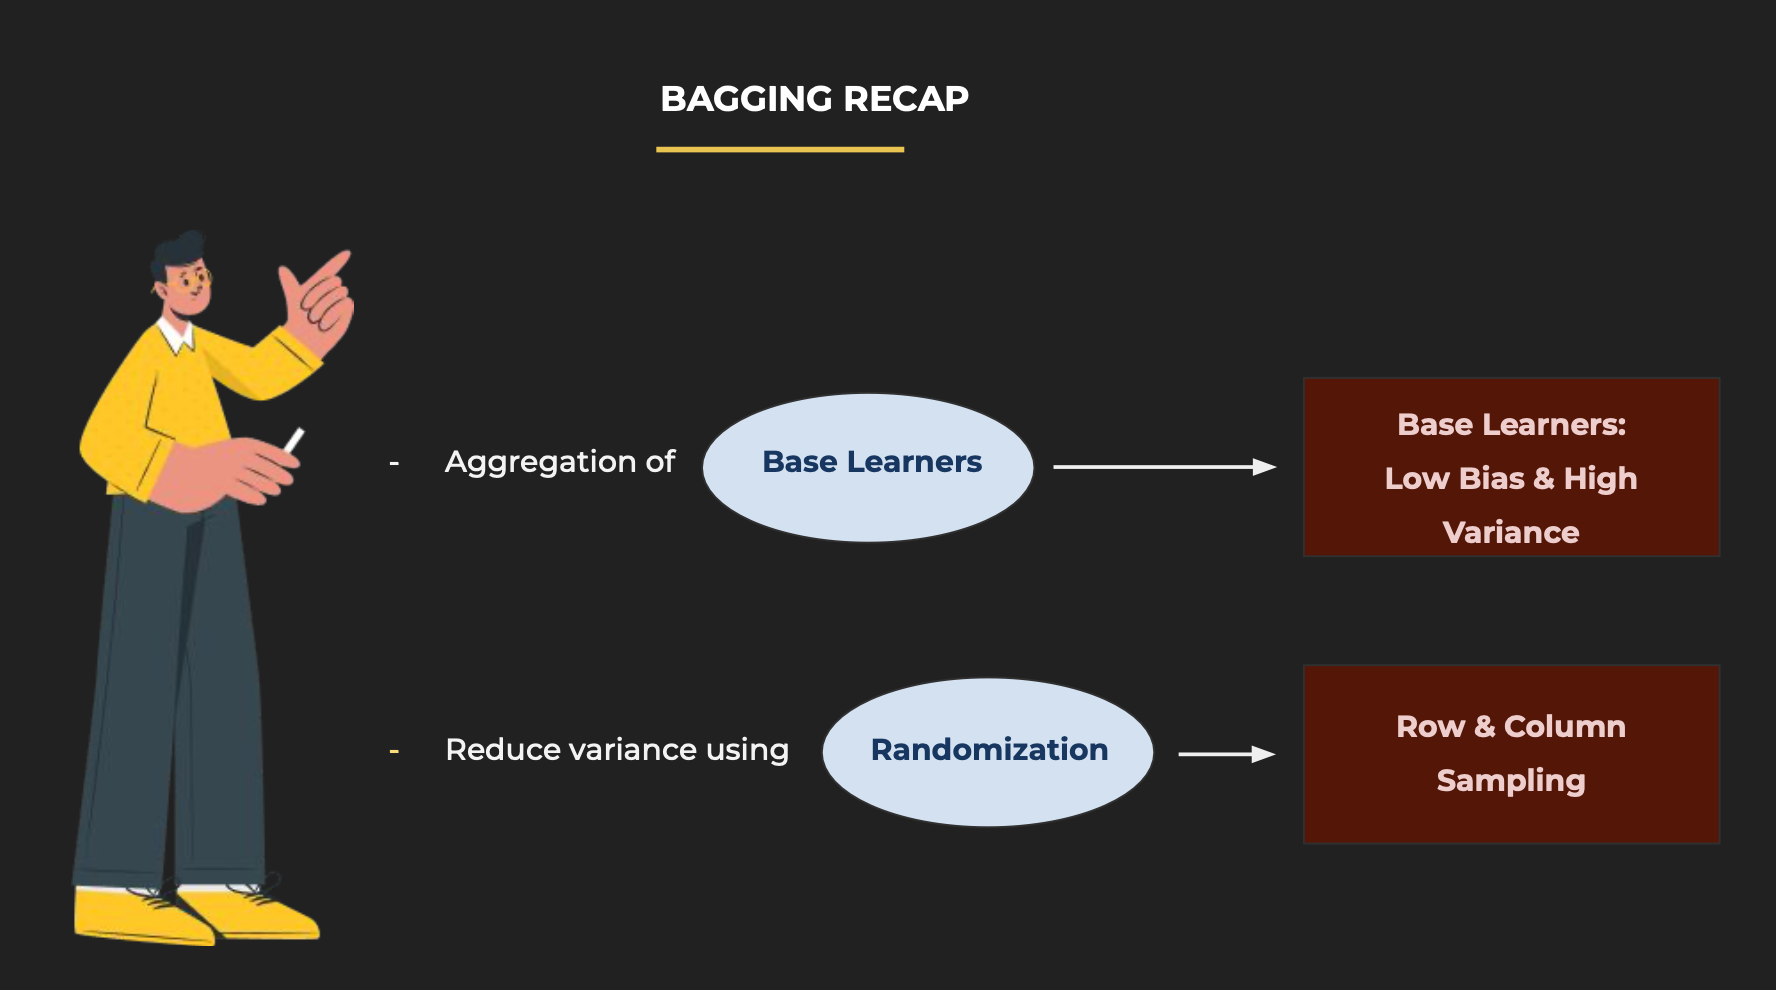




## Boosting Introduction

On the other hand, in boosting, we again have **base learners**



<br>

#### So, what's the nature of base learners in boosting ?



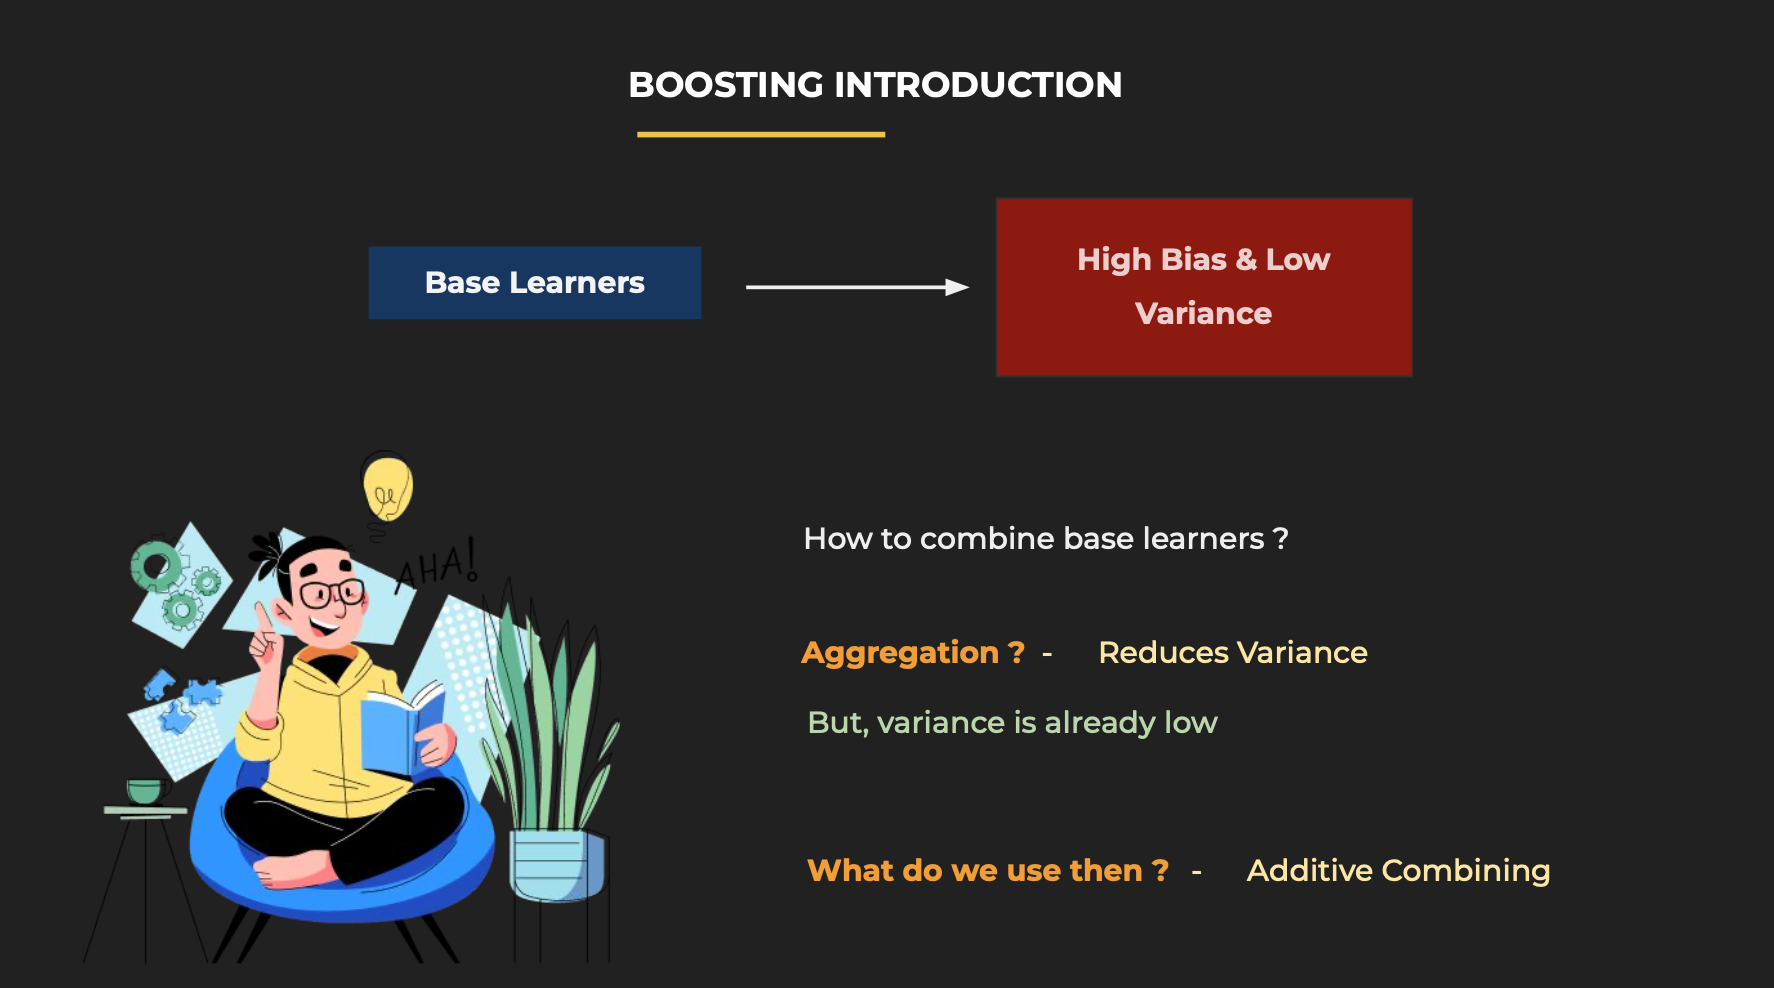

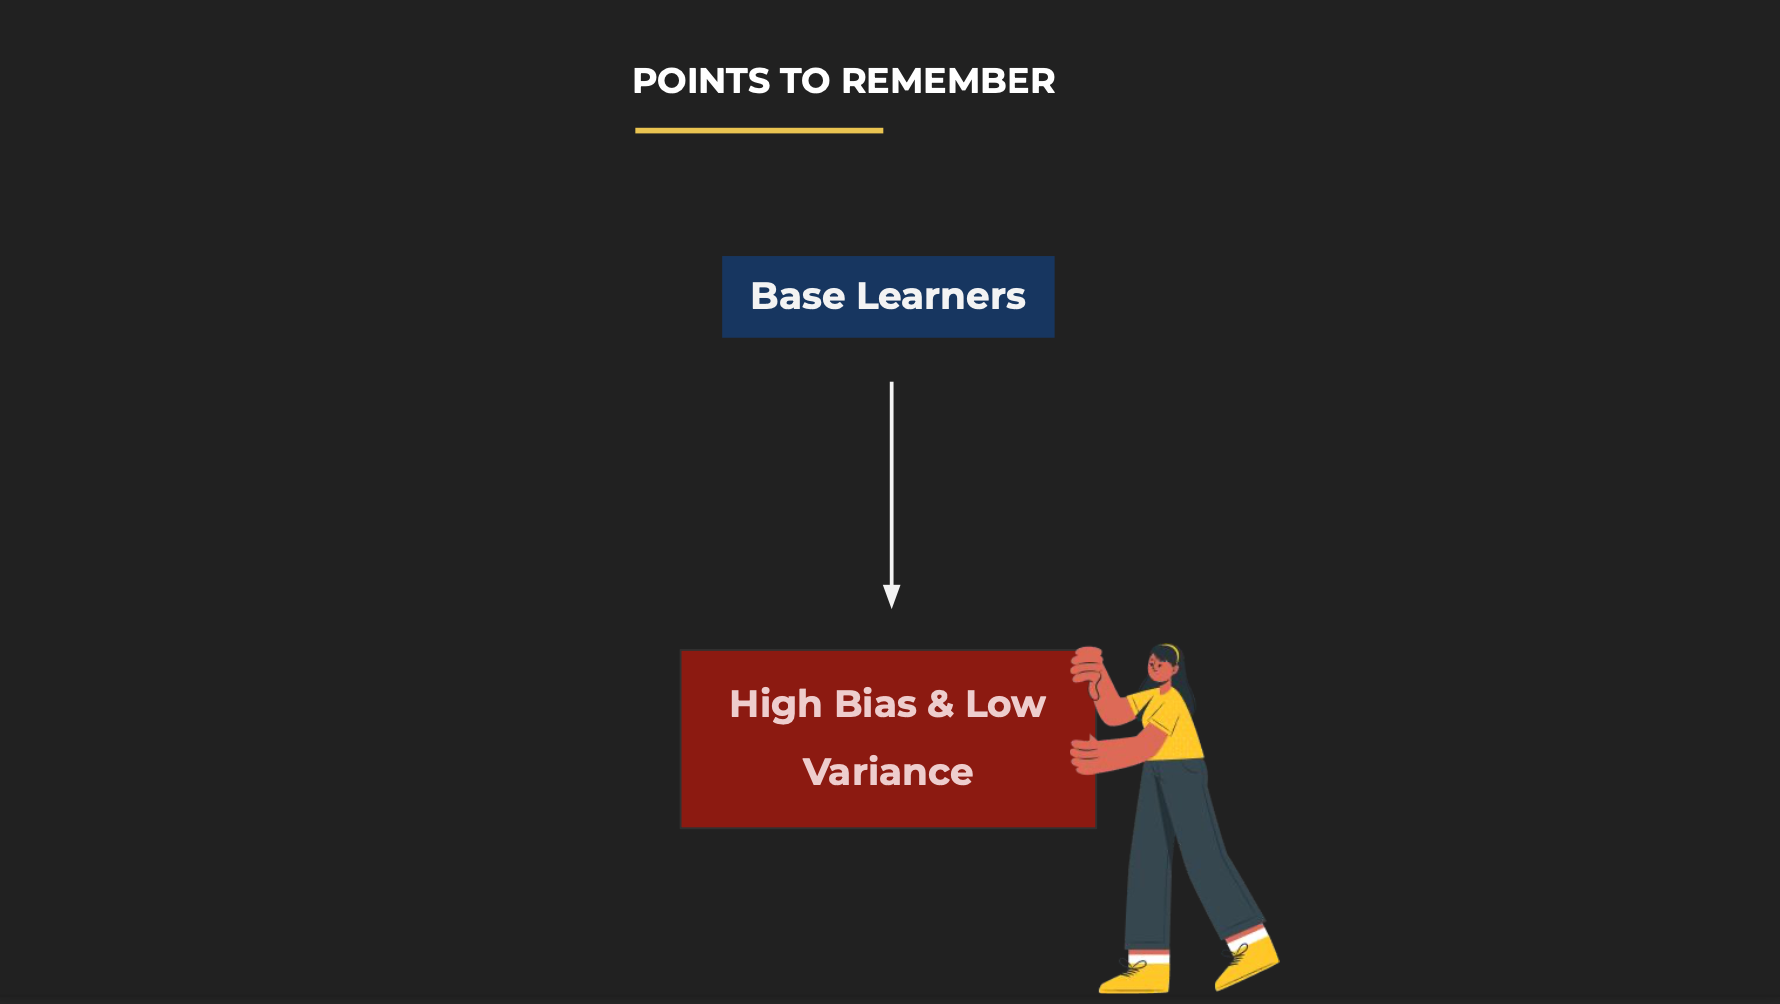

```
Quiz 1 - Check your understanding


Typically, high bias low variance models are:
a. Overfit
b. Underfit
c. Best fit

Correct option: b. Underfit

```

```
Quiz 2 - Try it out


Which of the following model are underfit models ?

a. Decision Stump (Decision Tree with depth = 1)
b. Decision Tree with depth = 20
c. Decision Tree with depth = 10
d. None of the above.

Correct option: a. Decision Stump
```

## Boosting Intuition - How do we combine base learners ?

Say, we have a regression problem i.e. target variable is continuous



Let's say we have dataset D and on that
- we'll start off by training a simplest model.






Q. What would be simplest model ?
- A mean model



**Stage 0**:
- This mean model give same average value for each datapoint.
- We represent mean model as $h_0(x)$
- $h_0(x)$ will predict $\hat{y}$

Q. What will be the error for each datapoint ?
- $e^0_i = y_i - \hat{y} $

<center><img src="https://drive.google.com/uc?id=1Xo8Oi7J8SIKEvxyxcYO1vD7IS2aXbbPn" width="900" height="500"> </center>

**Stage 1**:
- Here our base learner would be $h_1(x)$, which will be a shallow DT
- For $h_1(x)$ our dataset would be {$x_i$, $err^0_i$}.

- Let's create a table to understand this from **Stage0**
- At **stage0** we had a mean model, which will give 16 as $\hat{y}$ for each datapoint.

- Column $e_i$ is having errors from stage0, which $h_1(x)$ will try to fit on.

- That means errors from previous stage will act as actual y value for base learners, in this case $h_1(x)$

<center><img src="https://drive.google.com/uc?id=1KDLqPl12lCsHcq1xpARHDuqBy_-r8VoC" width="800" height="400"> </center>


- Let's consider $x_4$ datapoint from the table.
- $h_1(x)$ will try to predict and come close to value 4, but here we saw $\hat{y}$ comes out to be 1.
- The error, $e^1_i$ for stage1 would be 4-1 = 3

<center><img src="https://drive.google.com/uc?id=1_wyUIeczAkVqEMsrzQUdR0hEejelhkLx" width="800" height="500"> </center>


- Now we combine our base learners using this eqn
- $F_1(x) = \alpha_0 * h_0(x) +\alpha_1 * h_1(x)$
- This is our model after Stage 1, where $\alpha_0$ and $\alpha_0$ are weights which help in controlling overfit underfit tradeoff

<center><img src="https://drive.google.com/uc?id=1ceJlbl-rMNMEJehhGf8PgwLriPMxXZL4" width="800" height="300"> </center>


- Using $F_1(x) = \alpha_0 * h_0(x) +\alpha_1 * h_1(x)$ eqn, let's calculate error after **stage1**

- Again we are considering datapoint $x_4$
- Considering  aplha(s) =1 and replacing values from the table

<center><img src="https://drive.google.com/uc?id=1bddBdzrYZlBaIco85ij3LQqASClW415M" width="800" height="400"> </center>


**Stage2**:

- In stage2, our base learner would be $h_2(x)$, which will try to fit on the dataset {$x_i$, $err^1_i$}

- Again we will combine our base learners to get $F_2(x)$
-  $F_2(x) = \alpha_0 * h_0(x) +\alpha_1 * h_1(x)+\alpha_2 * h_2(x)$

- After each iteration of stage we are decreasing our error, and ideally we want error to be zero, but if that happens for each datapoint, then it will lead to overfitting.
- Since we are fitting so many base learners, there are high chances that our boosting algo will overfit.
<center><img src="https://drive.google.com/uc?id=1Zuo_uZEfYt1E1g98gRhyqXl9fukVAQgc" width="800" height="400"> </center>

**Stage M**

If we keep building the models in this way,

After $M$ Stages, the final model will be  
 * $F_M(x) = ∑_{i=0}^M α_i h_i(x)$

Here, $h(x)$ is
-  either a very simple mean model [for $h_0(x)$]
- a shallow tree which are underfit

And these weights ($α$'s) are calculated using optimization.

#### What is boosting doing intuitively?

Intuitively, we are iteratively building our models on the error of the previous models.

```
Quiz - Check your understanding

Which of the following statement is true?

a. Boosting is a sequential model building technique
b. We use weights to adjust the influence of model in final predicition
c. New model is build on the error of previous models
d. All of the above


Correct option: All of the above.

```

### Golf Example Summary



- It might be helpful to think of this boosting approach as a golfer initially whacking a golf ball towards the hole  but only getting as far as.
- The golfer then repeatedly taps the ball more softly, working the ball towards the hole, after reassessing direction and distance to the hole at each stage.
- The following diagram illustrates 5 strokes getting to the hole,including two strokes,and that overshoot the hole.

<center><img src="https://drive.google.com/uc?id=1XvwlbjjdmbYt-txN7fV9EaURvV2vDmjW" width="800" height="400"> </center>

#### **QUIZ**

```
What will be the most appropriate output of the first base learner in Boosting for regression?

a) Maximum value of the target variable present in the dataset
b) Minimum value of the target variable present in the dataset
c) Mean value of the target variable present in the dataset
d) Original Values of the target values present in the dataset

```
answer: C

#### **QUIZ**

```
After training a 4 Boosting model,
you notice that the residuals of final base learner as 0.

What can you say about this?

a) The model is optimal.
b) The model is overfitting.
c) The model is underfitting.
d) The final base learner is optimal.
```
answer: B

## Geometerical Interpretation

- In Stage 0 , we get mean model $h_0(x)$, which you could observe as orange line.
- After the mean model we can see the errors as green lines which seems to be high.
- After Stage 1, we get $F_1(x)$ model, which learnt from previous errors and now we can observe that errors for black line less than before.

<center><img src="https://drive.google.com/uc?id=1xOawBQN6KAOsvJdDraq3wy8AADnl2h3K" width="900" height="500"> </center>

The whole process will look like (gif):

Image source: https://drive.google.com/uc?id=1vr-XTgG7DNAuDCNTVs7oTFnp0ejLXNUC



<center><img src='https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/179/955/original/download_%281%29.gif?1770883730' width=700></center>



The whole process along with the reduction in residual looks as follows :

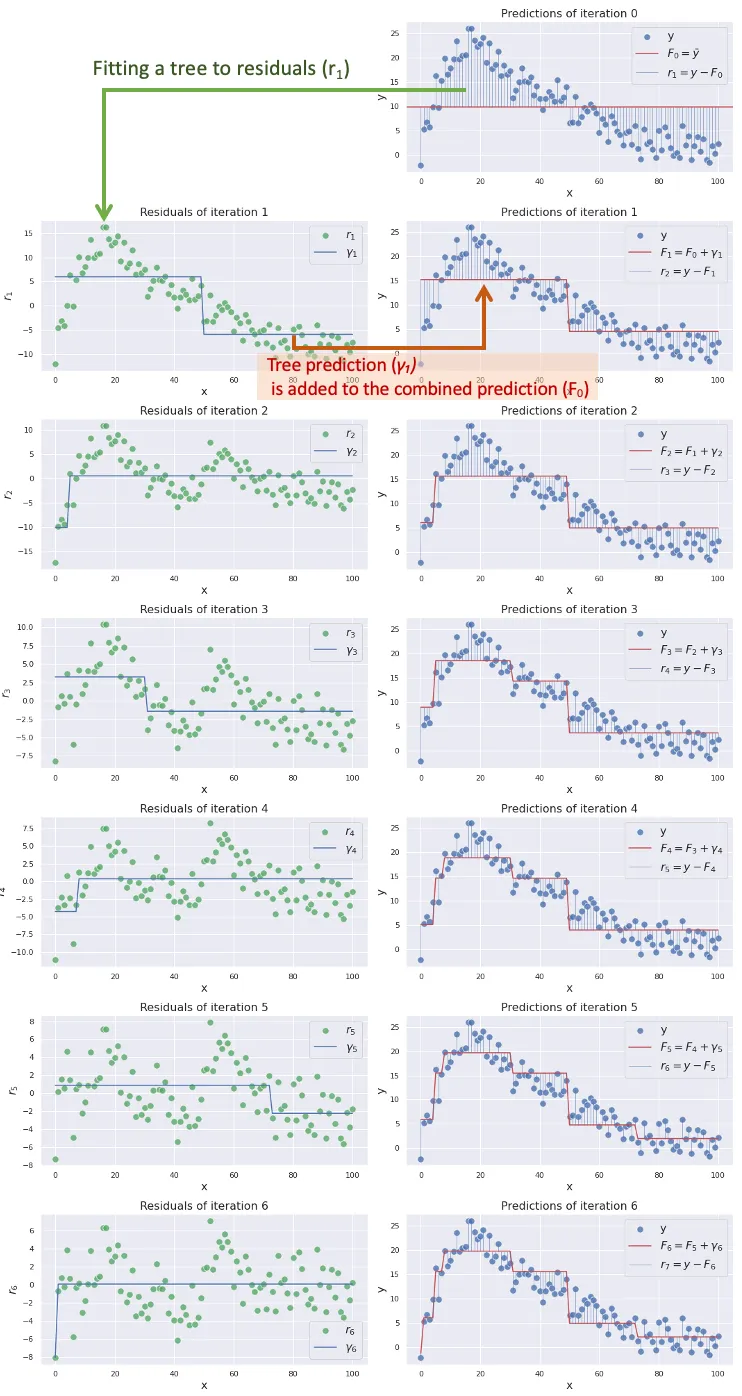




## How does Boosting work for classification?



Let us assume
- we have the data ($x_i,y_i$)
- but our values of $y_i$ are 0 or 1.

Now, we have the predict the probability of $y_i$ being 0 or 1 i.e $p_i$


<br>

#### Case 1: $y_i$ = 1
For model where $x_i$ = [0,1,3,1] and $y_i=1$
  * let assume $h_0(x_1)$ predicts 0.4

<br>

#### What will be the error here ?
- $error^0$ = 1 - 0.4 = 0.6
- Second model will fit the data on ($x_i, 0.6$)
- Suppose $h_1(x)$ = 0.2

#### What will be final model after stage 2 ?

- So, final model after second stage
- $F_1(x) = γ_0h_0(x) + y_1h_1(x)$ = 0.4 + 0.2 = 0.6

#### What will be residual?

Residual will be $y_i - F_1(x)$ = 1 - 0.6 = 0.4


We keep on fitting the models on the residual....





#### Case 2: $y_i$ = 0

Assume the same case,

For model where $x_i$ = [0,1,3,1] and $y_i= 0 $
  * let assume $h_0(x_1)$ predicts 0.4

<br>

#### What will be the residual after $F_0(x)$ or $h_0(x)$ ?

Residual = $y_i - F_0(x)$ = 0 - 0.4 = -0.4

Now, next model will fit on ($x_i, - 0.4$) and so on ..

Before implementing boosting using sklearn,
- lets look at hyperparams

## **Overfitting-Underfitting Trade-off**


#### How can we Regularize the GBDT model?

sklearn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

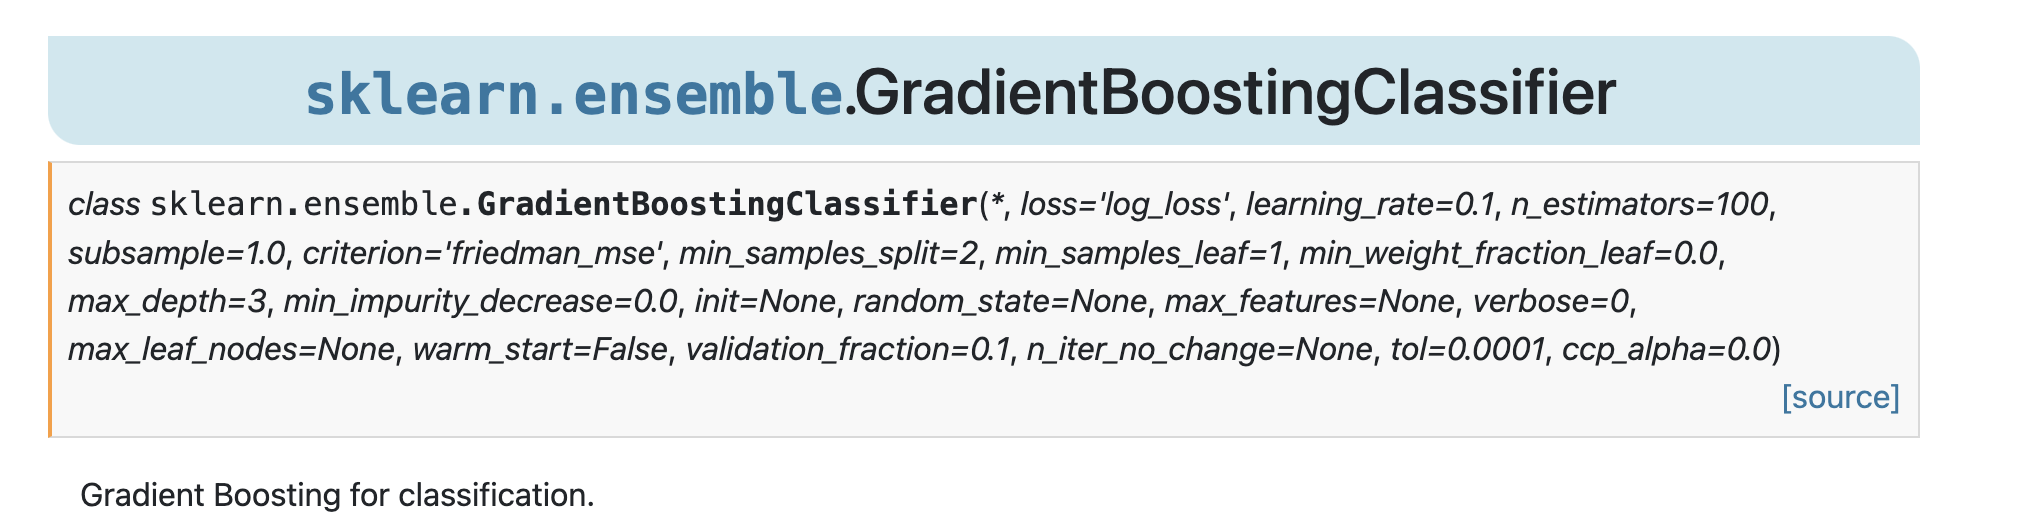




#### 1. $M$ - The number of base learners

#### What will happen if M increases?
As number of base learners increase, it is more likely that train error will go to 0.

Hence, the model will overfit.

**As $M$ increases, the model will overfit**

<br>



####2. The depth of base learners

#### What will happen if depth increases?

As depth increases,model will overfit

**How?**

Let's say we have deep DT for base learners i.e. overfit models.

- In that case, Within 4 or 5 models, we'll crazily overfit to noise.

Hence, we don't use deep DT as base learners





With great power comes great risk

The biggest risk of GBDT is
- it can overfit easily if we are not careful

So, in order to avoid that, we introduce another level of regularization



#### 3. Shrinkage or Learning rate ($\nu$)


We add a regularization term $𝜈$
to the model $F_m(x)$ s.t.
 * $F_m(x) = F_{m-1}(x) +𝜈\ γ_mh_m(x)$



<br>

#### What will be the value of ν (nu)?
This 𝜈 always lies between 0 and 1

<br>

#### What is ν doing intuitively?
Intuitively, ν is shrinking the impact of $m^{th}$ model so that models don't overfit easily

Think of it as an addition lever to control the overfit.

<br>

So, we can say that,

**as ν increases, chances of model overfitting increases**



Note: We have **same 𝜈 for all models in GBDT**



### **QUIZ**

```
What happens to the boosting model when we keep learning rate (𝜈) = 0 and (ν) = 1?

a) v=0 -> Underfit; v=1 -> Overfit
b) v=0 -> Overfit; v=1 -> Underfit
c) v=0 -> Underfit; v=1 -> Undefit
d) v=0 -> Overfit; v=1 -> Overfit

```
answer: A

#### Question: What should be done to $M$ if 𝜈 is decreased to keep the performance same?

Number of **base learners should be increased** because as we are decresing 𝜈,
- we are restricting base learners contribution
- due to which the error increases


We use 𝜈 even when the $γ$ is there to avoid overfit, as there are high chances of overfitting

## UseCase - EMG Signal Classification



#### Problem Statement:
- Your task is to classify these EMG signals into 20 different physical actions
- This will then be used for controlling the robotics arm.

#### What is EMG (ElectroMioGraphy) ?
  - Technique to study electrical signals produced by muscular movement.

#### Dataset
- You have a dataset of EMG signals from 4 subjects/people.

#### How was the data collected ?
  - Subject was asked to perform specific physical actions
  - Signals produced due to that movement were recorded over time.
  - 8 channels were used to record the signals
  - Channels here correspond to muscles\
    For eg: Right-hand bicep
  - Frequency : 10 $ms^{-1}$

Now, lets import some libs at first.

 Source: https://archive.ics.uci.edu/ml/datasets/EMG+Physical+Action+Data+Set

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sklearn

#### Extracting data

In [ ]:
!pip install gdown==4.6.0

In [ ]:
!gdown 1h86M8si2YT-aI4Zec1MeMP_mPYsLPy5F

Downloading...
From: https://drive.google.com/uc?id=1h86M8si2YT-aI4Zec1MeMP_mPYsLPy5F
To: /content/emg.rar
100% 18.6M/18.6M [00:00<00:00, 20.1MB/s]


In [ ]:
# x is extract

!unrar x "./emg.rar" "./"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from ./emg.rar

Creating    ./EMG Physical Action Data Set                            OK
Extracting  ./EMG Physical Action Data Set/readme.txt                      0%  OK 
Creating    ./EMG Physical Action Data Set/sub1                       OK
Creating    ./EMG Physical Action Data Set/sub1/Aggressive            OK
Creating    ./EMG Physical Action Data Set/sub1/Aggressive/log        OK
Extracting  ./EMG Physical Action Data Set/sub1/Aggressive/log/Elbowing.log       0%  OK 
Extracting  ./EMG Physical Action Data Set/sub1/Aggressive/log/FrontKicking.log       0%  1%  OK 
Extracting  ./EMG Physical Action Data Set/sub1/Aggressive/log/Hamering.log       1%  OK 
Extracting  ./EMG Physical Action Data Set/sub1/Aggressive/log/Headering.log       1%  2%  OK 
Extracting  ./EMG Physical Action Data Set/sub1/Aggressive/log/Kneeing.log       2%  OK

#### Visualizing file structure

In [ ]:
!sudo apt install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tree is already the newest version (2.0.2-1).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


In [ ]:
!tree "./EMG Physical Action Data Set/sub1"

./EMG Physical Action Data Set/sub1
├── Aggressive
│   ├── log
│   │   ├── Elbowing.log
│   │   ├── FrontKicking.log
│   │   ├── Hamering.log
│   │   ├── Headering.log
│   │   ├── Kneeing.log
│   │   ├── Pulling.log
│   │   ├── Punching.log
│   │   ├── Pushing.log
│   │   ├── SideKicking.log
│   │   └── Slapping.log
│   └── txt
│       ├── Elbowing.txt
│       ├── Frontkicking.txt
│       ├── Hamering.txt
│       ├── Headering.txt
│       ├── Kneeing.txt
│       ├── Pulling.txt
│       ├── Punching.txt
│       ├── Pushing.txt
│       ├── Sidekicking.txt
│       └── Slapping.txt
└── Normal
    ├── log
    │   ├── Bowing.log
    │   ├── Clapping.log
    │   ├── Handshaking.log
    │   ├── Hugging.log
    │   ├── Jumping.log
    │   ├── Running.log
    │   ├── Seating.log
    │   ├── Standing.log
    │   ├── Walking.log
    │   └── Waving.log
    └── txt
        ├── Bowing.txt
        ├── Clapping.txt
        ├── Handshaking.txt
        ├── Hugging.txt
        ├── Jumping.txt
        ├── 

Here if you see for subject 1 , we have  sub folders
- aggressive and
- normal

These folders mention the aggresive and normal activities respectively with corresponding log and txt files

We will use txt files


Let's see one of the folder from above

In [ ]:
!ls -lrt ./EMG\ Physical\ Action\ Data\ Set/sub1/Aggressive/txt/

total 3768
-rw-r--r-- 1 root root 361096 Feb  7  2010 Slapping.txt
-rw-r--r-- 1 root root 388912 Feb  7  2010 Sidekicking.txt
-rw-r--r-- 1 root root 379428 Feb  7  2010 Pushing.txt
-rw-r--r-- 1 root root 379597 Feb  7  2010 Punching.txt
-rw-r--r-- 1 root root 387656 Feb  7  2010 Pulling.txt
-rw-r--r-- 1 root root 398523 Feb  7  2010 Kneeing.txt
-rw-r--r-- 1 root root 350285 Feb  7  2010 Headering.txt
-rw-r--r-- 1 root root 402363 Feb  7  2010 Hamering.txt
-rw-r--r-- 1 root root 390158 Feb  7  2010 Frontkicking.txt
-rw-r--r-- 1 root root 398095 Feb  7  2010 Elbowing.txt


#### Reading data

Now, let's see what is the data in slapping.txt

In [ ]:
!cat ./EMG\ Physical\ Action\ Data\ Set/sub1/Aggressive/txt/Slapping.txt

Streaming output truncated to the last 5000 lines.
-814	-49	-25	64	-746	174	-1034	-301
-1344	252	-90	90	158	107	-998	-506
-1674	498	-129	162	988	77	-1136	-602
-1801	537	-86	-120	692	67	-1458	-778
-1735	461	-45	-397	320	143	-1781	-1404
-1674	363	8	-82	-295	90	-2096	-2259
-1581	254	69	111	-274	58	-2223	-2456
-1296	108	12	-76	-11	42	-2312	-1387
-1010	-4	-52	-15	-217	-11	-2577	-130
-740	-75	-21	122	-408	-33	-2707	716
-554	-21	18	221	-525	-37	-2573	1085
-444	-12	1	65	772	-94	-2385	1056
-272	-99	33	-10	2822	-141	-2223	1270
-218	-130	64	38	3851	-143	-2079	1452
-156	-92	61	-21	3725	-126	-2039	1332
-117	-87	62	-23	3428	-105	-2076	1150
-66	-98	36	-72	2968	-125	-2009	710
2	-137	23	-18	2125	-116	-1962	389
67	-203	15	6	2243	-55	-1962	448
103	-231	52	12	2378	-22	-2043	731
100	-215	93	10	2321	-26	-1781	817
55	-122	83	4	2813	-63	-1262	621
33	-106	14	2	3474	-68	-941	535
59	-98	-4	18	2711	-55	-774	451
90	-145	-35	32	1721	-74	-375	408
216	-277	-56	35	1474	-66	-158	304
281	-297	-47	56	-61	-125	-216	230
25

**Key observations**

* We got eight columns of the data which corresponds to eight electrodes
* We are collecting data 10 times per millisecond,
- each row gives the data for every 0.1 millisecond

After this, we perform series of preprocessing on the data

#### Summary of preprocessing

**Preprocessing Post Read**

link: https://colab.research.google.com/drive/1jRl6U-gGxTvT1FHGzMW-5BDAhQ6ON6om?usp=sharing

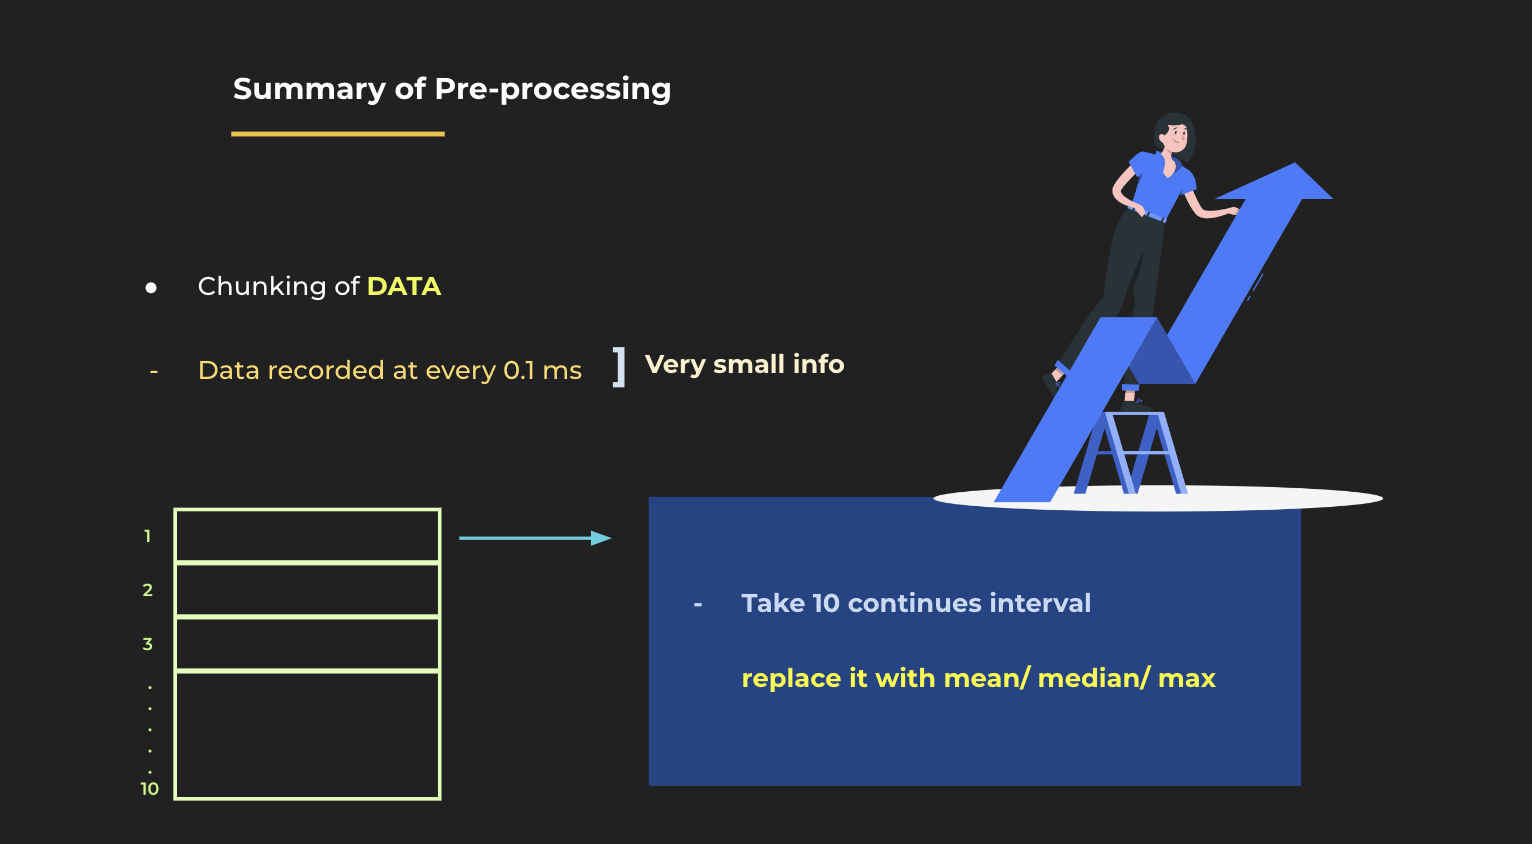

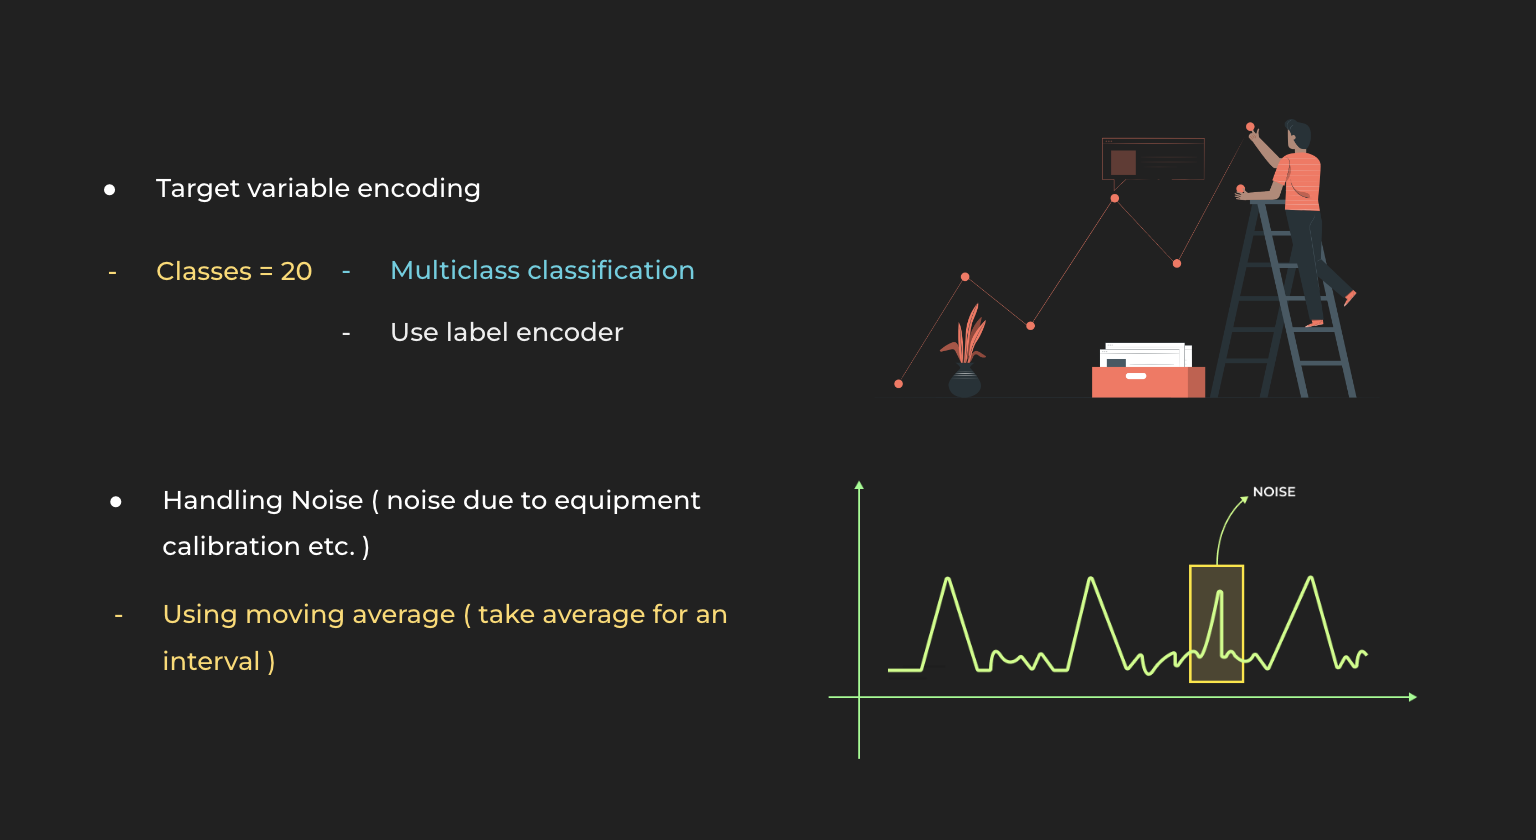

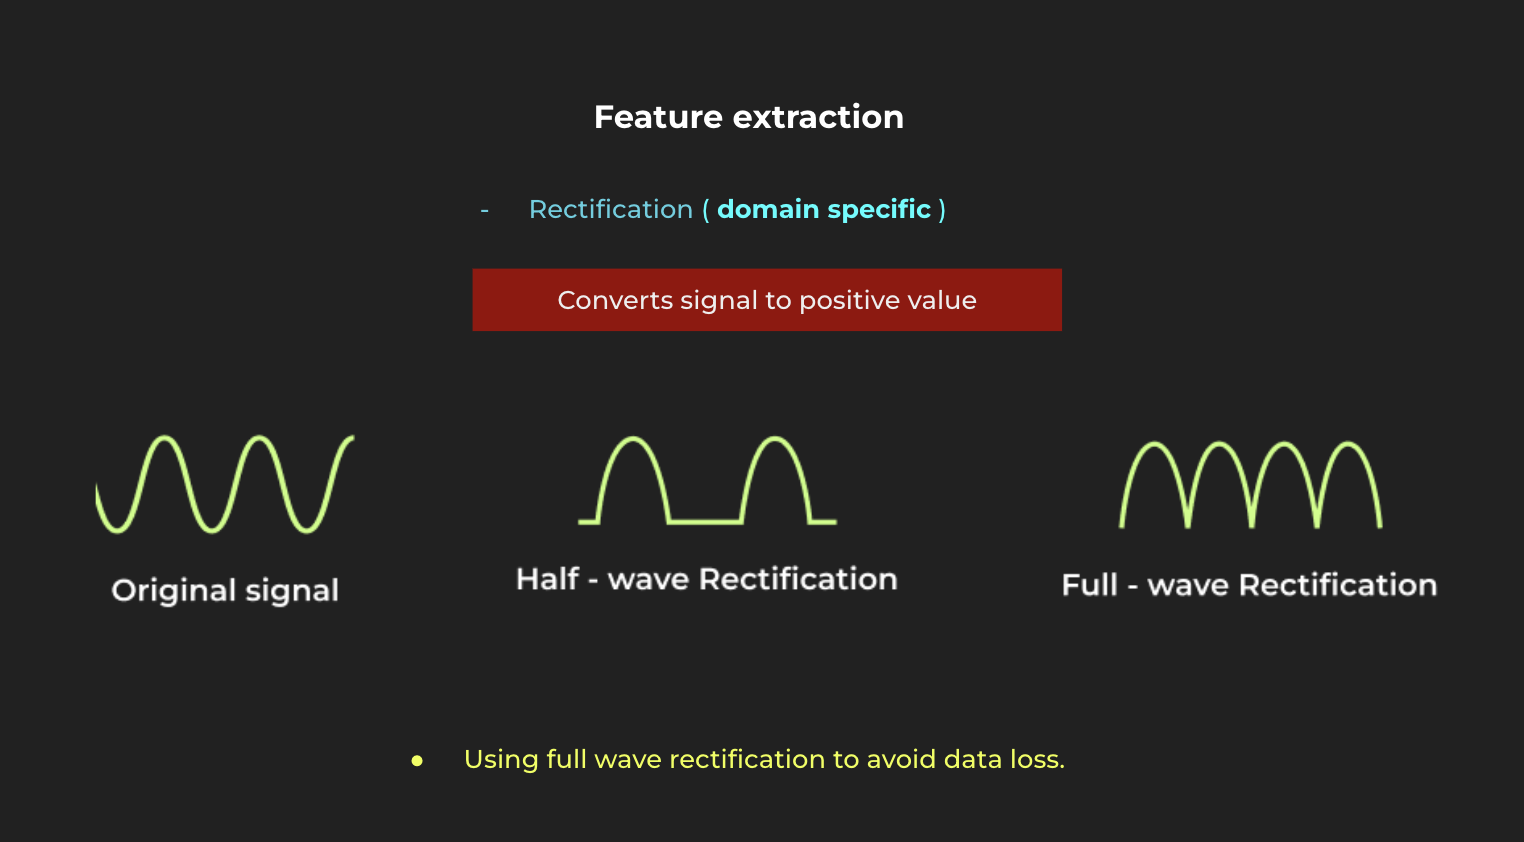

#### Preprocessed Data


In [ ]:
import pickle

!gdown 171Yoe_GSapyrmOnD9oBzHWNOD_OnQs0F
!gdown 1hnIlTPW3AMeB69EbeaXCRIrpMVT1Vwmc
!gdown 1nZtB_RtxMg_MgoRczb8UWQX-AEK_l3qE
!gdown 1zLDUErwKdmF-RacOyHEuI_z_46LssQtP


with open('X_train.pickle', 'rb') as handle:
    X_train = pickle.load(handle)

with open('X_test.pickle', 'rb') as handle:
    X_test = pickle.load(handle)

with open('Y_train.pickle', 'rb') as handle:
    y_train = pickle.load(handle)

with open('Y_test.pickle', 'rb') as handle:
    y_test = pickle.load(handle)

Downloading...
From: https://drive.google.com/uc?id=171Yoe_GSapyrmOnD9oBzHWNOD_OnQs0F
To: /content/Y_test.pickle
100% 31.7k/31.7k [00:00<00:00, 50.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hnIlTPW3AMeB69EbeaXCRIrpMVT1Vwmc
To: /content/X_test.pickle
100% 253k/253k [00:00<00:00, 18.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nZtB_RtxMg_MgoRczb8UWQX-AEK_l3qE
To: /content/Y_train.pickle
100% 126k/126k [00:00<00:00, 19.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zLDUErwKdmF-RacOyHEuI_z_46LssQtP
To: /content/X_train.pickle
100% 1.01M/1.01M [00:00<00:00, 33.5MB/s]


### Modeling

#### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier as DTC
from sklearn import tree
from sklearn.model_selection import GridSearchCV

params = {
    "max_depth" : [3, 5, 7, 10, 15],
    "max_leaf_nodes" : [20, 40, 60]
}

model1 = DTC()
clf = GridSearchCV(model1, params, scoring = "accuracy", cv=5)

clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [3, 5, 7, 10, 15],
                         'max_leaf_nodes': [20, 40, 60]},
             scoring='accuracy')

Lets see the results of our GridSearch

In [ ]:
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'max_depth': 3, 'max_leaf_nodes': 20} Mean_score: 0.34208509132931136 Rank: 13
Parameters:{'max_depth': 3, 'max_leaf_nodes': 40} Mean_score: 0.34208509132931136 Rank: 13
Parameters:{'max_depth': 3, 'max_leaf_nodes': 60} Mean_score: 0.34208509132931136 Rank: 13
Parameters:{'max_depth': 5, 'max_leaf_nodes': 20} Mean_score: 0.446599880417056 Rank: 11
Parameters:{'max_depth': 5, 'max_leaf_nodes': 40} Mean_score: 0.44666327184646243 Rank: 10
Parameters:{'max_depth': 5, 'max_leaf_nodes': 60} Mean_score: 0.4464729768892788 Rank: 12
Parameters:{'max_depth': 7, 'max_leaf_nodes': 20} Mean_score: 0.6328638103920514 Rank: 9
Parameters:{'max_depth': 7, 'max_leaf_nodes': 40} Mean_score: 0.6349567331371658 Rank: 8
Parameters:{'max_depth': 7, 'max_leaf_nodes': 60} Mean_score: 0.6351470482058436 Rank: 7
Parameters:{'max_depth': 10, 'max_leaf_nodes': 20} Mean_score: 0.6976794754761447 Rank: 5
Parameters:{'max_depth': 10, 'max_leaf_nodes': 40} Mean_score: 0.773402086487067 Rank: 4
Parameters:

#### So whats the best estimator and score ?

In [ ]:
print(clf.best_estimator_)


DecisionTreeClassifier(max_depth=15, max_leaf_nodes=60)


In [ ]:
clf = DTC(**clf.best_params_)

In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, max_leaf_nodes=60)

##### Train score

In [ ]:
clf.score(X_train, y_train)

0.8223617453069508

##### Test score


In [ ]:
clf.score(X_test, y_test)

0.8125792543748415

#### RF

In [ ]:
from sklearn.ensemble import RandomForestClassifier as RFC
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV
import datetime as dt

params = {
    "n_estimators": [10,25,50,100,150,200],
    "max_depth" : [3, 5, 10, 15, 20],
    "max_leaf_nodes" : [20, 40, 80]
}

rfc = RFC(n_jobs = -1)
clf = RandomizedSearchCV(rfc, params, scoring = "accuracy", cv=3, n_jobs = -1, verbose = 1)

start = dt.datetime.now()
clf.fit(X_train, y_train)
end = dt.datetime.now()

Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'n_estimators': 200, 'max_leaf_nodes': 40, 'max_depth': 3} Mean_score: 0.6796676813800101 Rank: 10
Parameters:{'n_estimators': 50, 'max_leaf_nodes': 40, 'max_depth': 20} Mean_score: 0.8515981735159818 Rank: 3
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 5} Mean_score: 0.7723871131405379 Rank: 8
Parameters:{'n_estimators': 25, 'max_leaf_nodes': 40, 'max_depth': 15} Mean_score: 0.8460172501268391 Rank: 5
Parameters:{'n_estimators': 25, 'max_leaf_nodes': 40, 'max_depth': 20} Mean_score: 0.8489345509893454 Rank: 4
Parameters:{'n_estimators': 10, 'max_leaf_nodes': 20, 'max_depth': 20} Mean_score: 0.7743531202435312 Rank: 6
Parameters:{'n_estimators': 25, 'max_leaf_nodes': 80, 'max_depth': 5} Mean_score: 0.7631912734652461 Rank: 9
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 80, 'max_depth': 20} Mean_score: 0.8929477422628107 Rank: 1
Parameters:{'n_estimators': 25, 'max_leaf_nodes': 80, 'max_depth': 20} Mean_score: 0.8812151192288179 Rank: 2
Parameter

Notice that,

The performance of RF (0.89) is better than DT (0.81)

In [ ]:
print(f"Time taken for fits : {end - start}")

Time taken for fits : 0:00:52.106677


In [ ]:
print(clf.best_estimator_)

RandomForestClassifier(max_depth=20, max_leaf_nodes=80, n_estimators=150,
                       n_jobs=-1)


In [ ]:
rf = clf.best_estimator_

rf.fit(X_train, y_train)

print("Model acc",rf.score(X_test, y_test))



Model acc 0.8934821202130357


#### GBDT


Instrutor Note: GBDT takes lot of time to train. Kindly run it beforehand.

In [ ]:
params = {
    "n_estimators": [50,100,150,200],
    "max_depth" : [3, 4, 5, 7],
    "max_leaf_nodes" : [20, 40, 80],
    "learning_rate": [0.1, 0.2, 0.3]
}

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.model_selection import RandomizedSearchCV
import datetime as dt


gbc = GBC()
clf = RandomizedSearchCV(gbc, params, scoring = "accuracy", cv=3, n_jobs = -1, verbose = 1)

start = dt.datetime.now()

clf.fit(X_train, y_train)

end = dt.datetime.now()



Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
res = clf.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'n_estimators': 200, 'max_leaf_nodes': 20, 'max_depth': 5, 'learning_rate': 0.1} Mean_score: 0.9495180111618469 Rank: 5
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 80, 'max_depth': 5, 'learning_rate': 0.2} Mean_score: 0.9519913749365805 Rank: 4
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 80, 'max_depth': 4, 'learning_rate': 0.3} Mean_score: 0.9482496194824962 Rank: 7
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 20, 'max_depth': 5, 'learning_rate': 0.3} Mean_score: 0.9528792491121258 Rank: 3
Parameters:{'n_estimators': 50, 'max_leaf_nodes': 80, 'max_depth': 3, 'learning_rate': 0.2} Mean_score: 0.9209791983764587 Rank: 9
Parameters:{'n_estimators': 50, 'max_leaf_nodes': 40, 'max_depth': 3, 'learning_rate': 0.2} Mean_score: 0.9207255200405885 Rank: 10
Parameters:{'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 5, 'learning_rate': 0.1} Mean_score: 0.948947234906139 Rank: 6
Parameters:{'n_estimators': 200, 'max_leaf_nodes': 20, 'max_depth': 7, 'learni

In [ ]:
print(f"Time taken for fits : {end - start}")

Time taken for fits : 1:00:39.977472


In [ ]:
print(clf.best_estimator_)

GradientBoostingClassifier(learning_rate=0.3, max_depth=7, max_leaf_nodes=40,
                           n_estimators=200)


In [ ]:
gbc = clf.best_estimator_

gbc.fit(X_train, y_train)

print("Model acc",gbc.score(X_test, y_test))



Model acc 0.9748922140502155


Notice that
- It took us approx 1 hr to hyperparam tune sklearn GBDT  (slow)
- Test accuracy: 0.96 (better than RF)


## Interactive GBDT




let's visualize the process of training a GBDT

<center><img src="https://drive.google.com/uc?id=1MpaM7diik3LBreIi4QUddMVjva_psEu7" width="900" height="600"> </center>

- Click [here](https://arogozhnikov.github.io/2016/07/05/gradient_boosting_playground.html) and play

## **Feature Importance**

#### How do we find feature importance in GBDT ?

We simply find the feature importance of feature in each tree and
- then take the average of these values to get over-all feature importance.


#### Code walkthrough

[0.14761092 0.07742957 0.10749733 0.14408435 0.18341566 0.127482
 0.10629175 0.10618842]


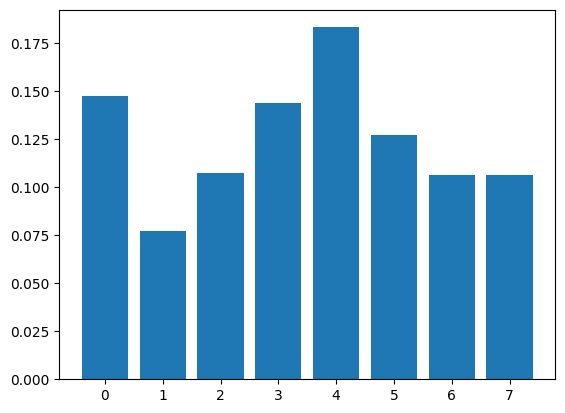

In [ ]:
print(gbc.feature_importances_)

plt.bar(range(len(gbc.feature_importances_)), gbc.feature_importances_)
plt.show()

## What happens at train and test time ?


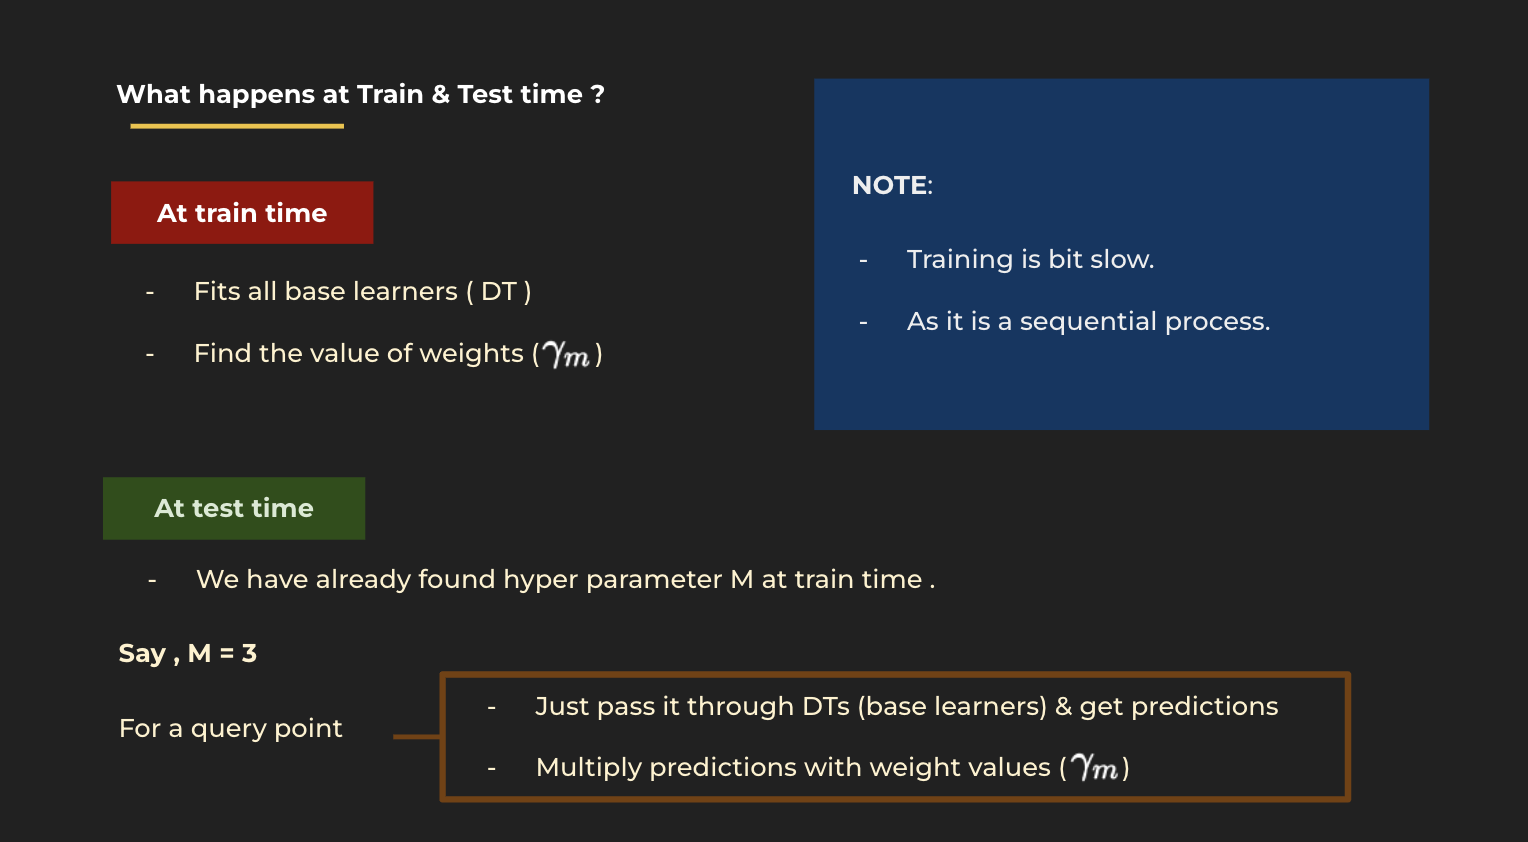

GBDT is the sequential model, Hence it is slow to train

#### How can we speed up GBDT?

* Row sampling and column sampling can speed up the model a little
* While building each base leraners we can apply **parallelisation**, i.e one sub-tree can be built on a core and the other sub-tree can be built on another core
* Even for bulding a single tree, **we have to calculate entropy of many features, this can be parallelised**

## **Impact of outliers**





#### Question: Will outliers impact GBDT?

Outliers can impact GBDT

- Each model is fit on the residual of the previous model
- Outliers will have higher residual values
- So, so gradient boosting will focus a large amount of its attention on reducing residual for these points.

#### Question: How to handle outliers?
1. Remove outliers
2. Specialized or smart loss functions to handle outliers


#### What changes can we make in the loss function so that the model be robust to outliers?

* We can use **Root mean squared error**
* We can use absolute values of the error



**QUIZ**

```
Which of the following is true?

1. GBDT is not impacted with Outliers
2. GBDT is impacted with Outliers
3. MSE is not impacted with Outliers in the data
4. All of the above expect 1
```

**ANSWER**
2. GBDT is impacted with Outliers

## Stochastic Gradient Boosting

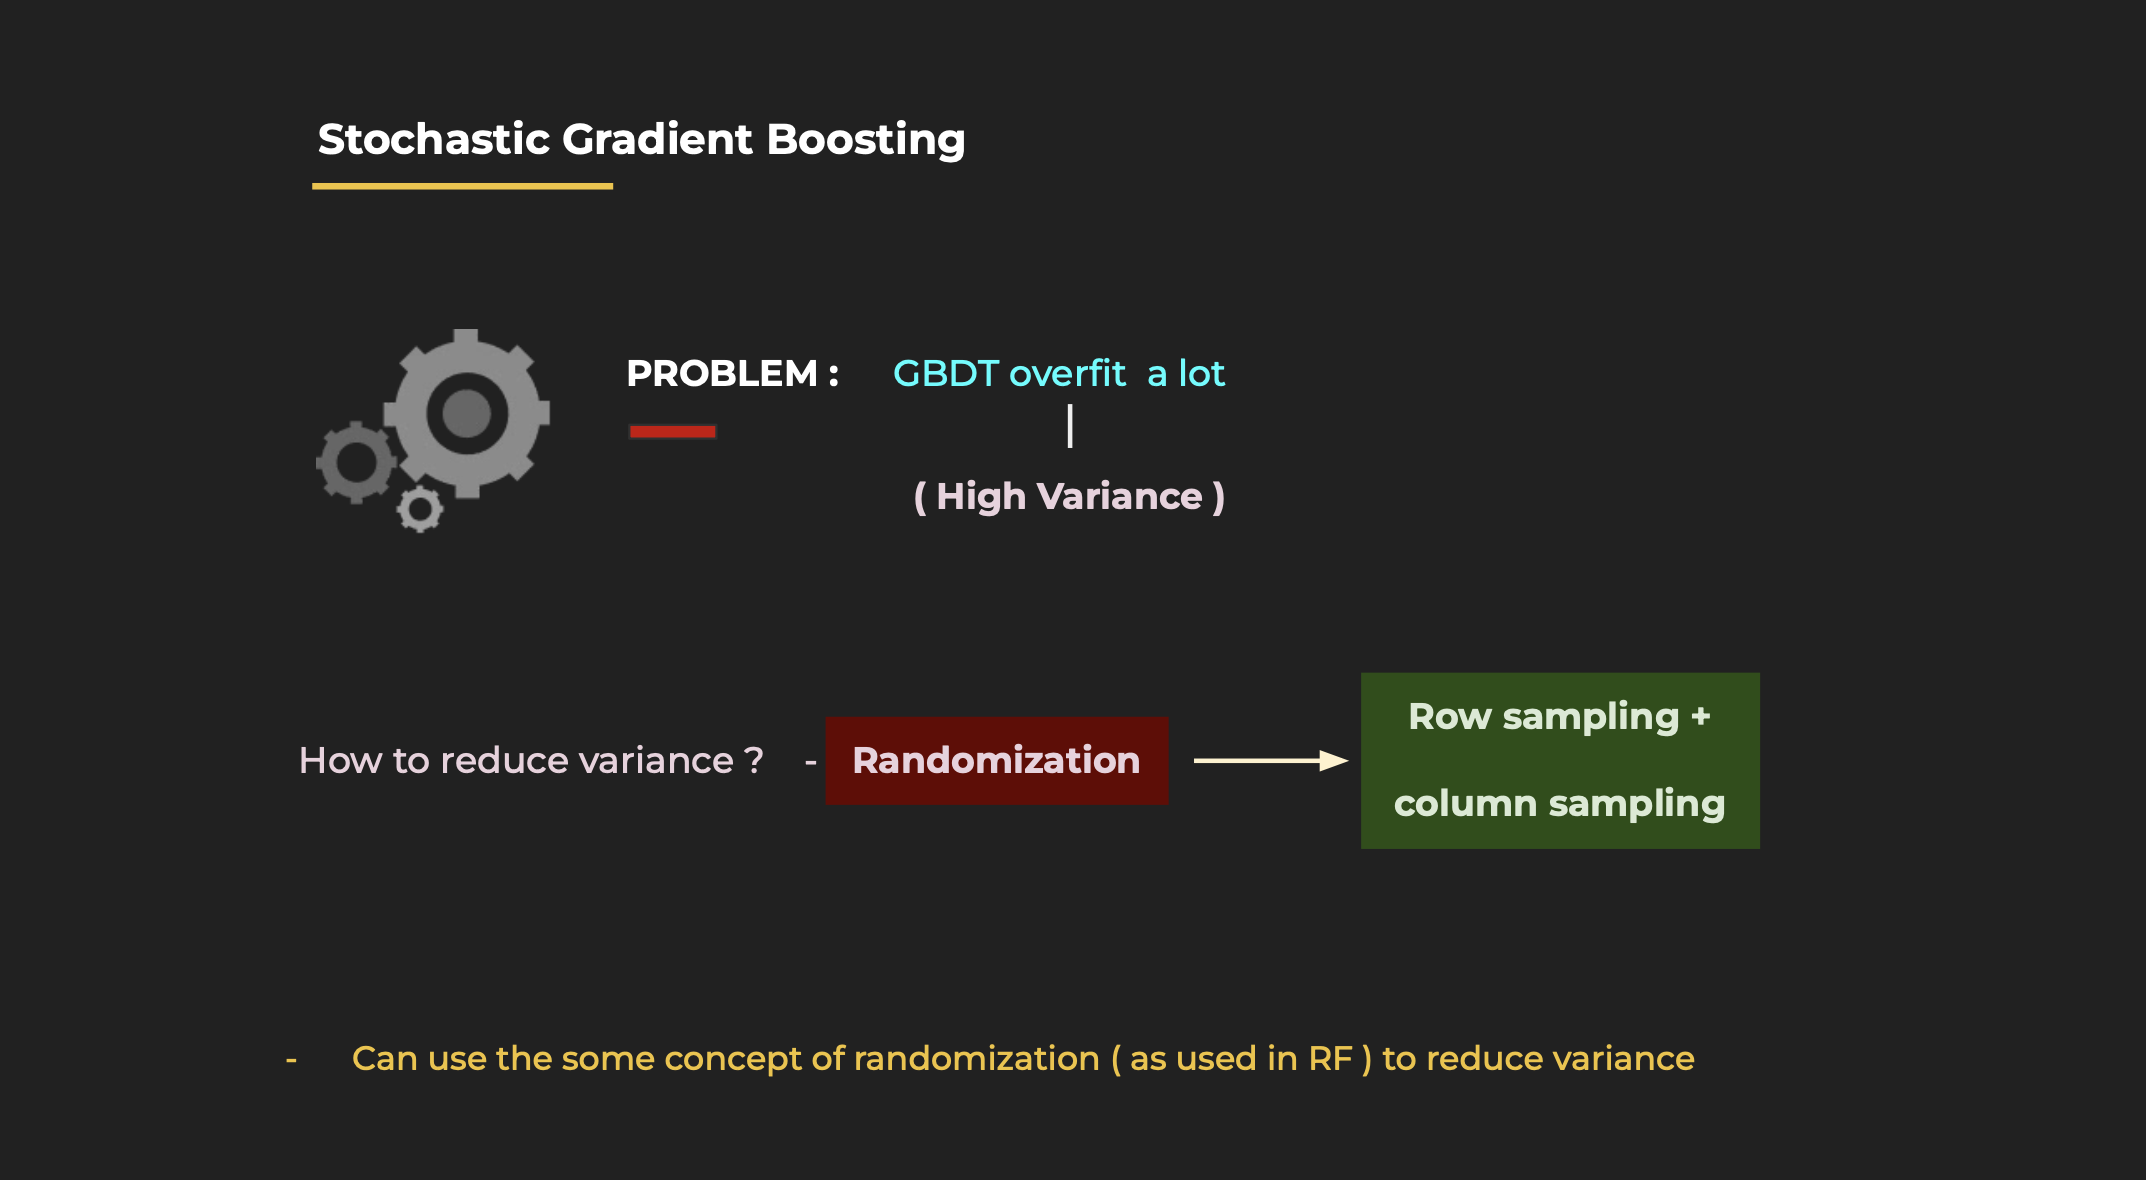

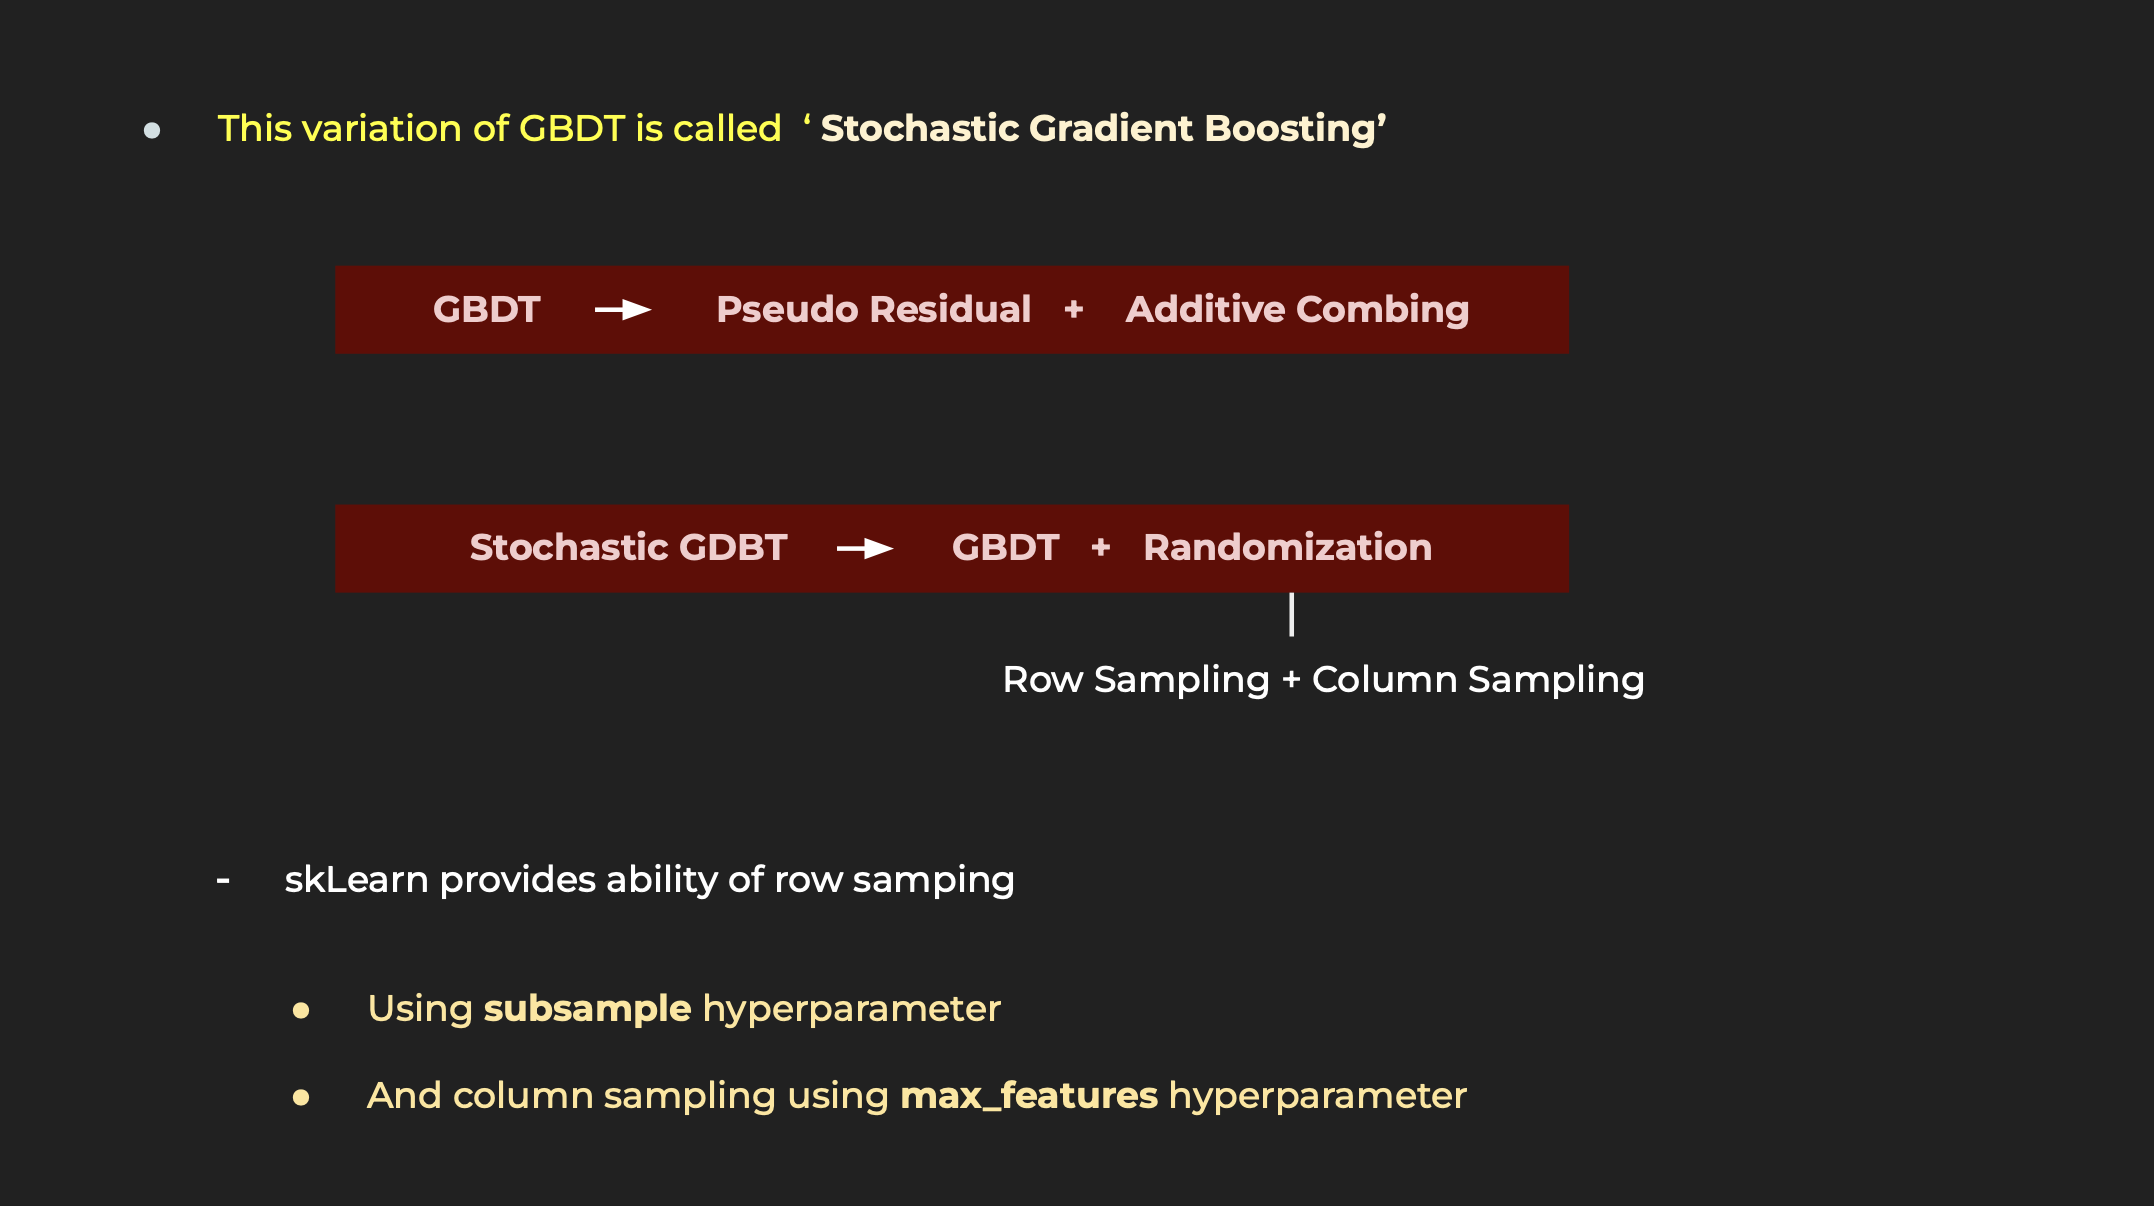

sklearn documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html

## XGBoost

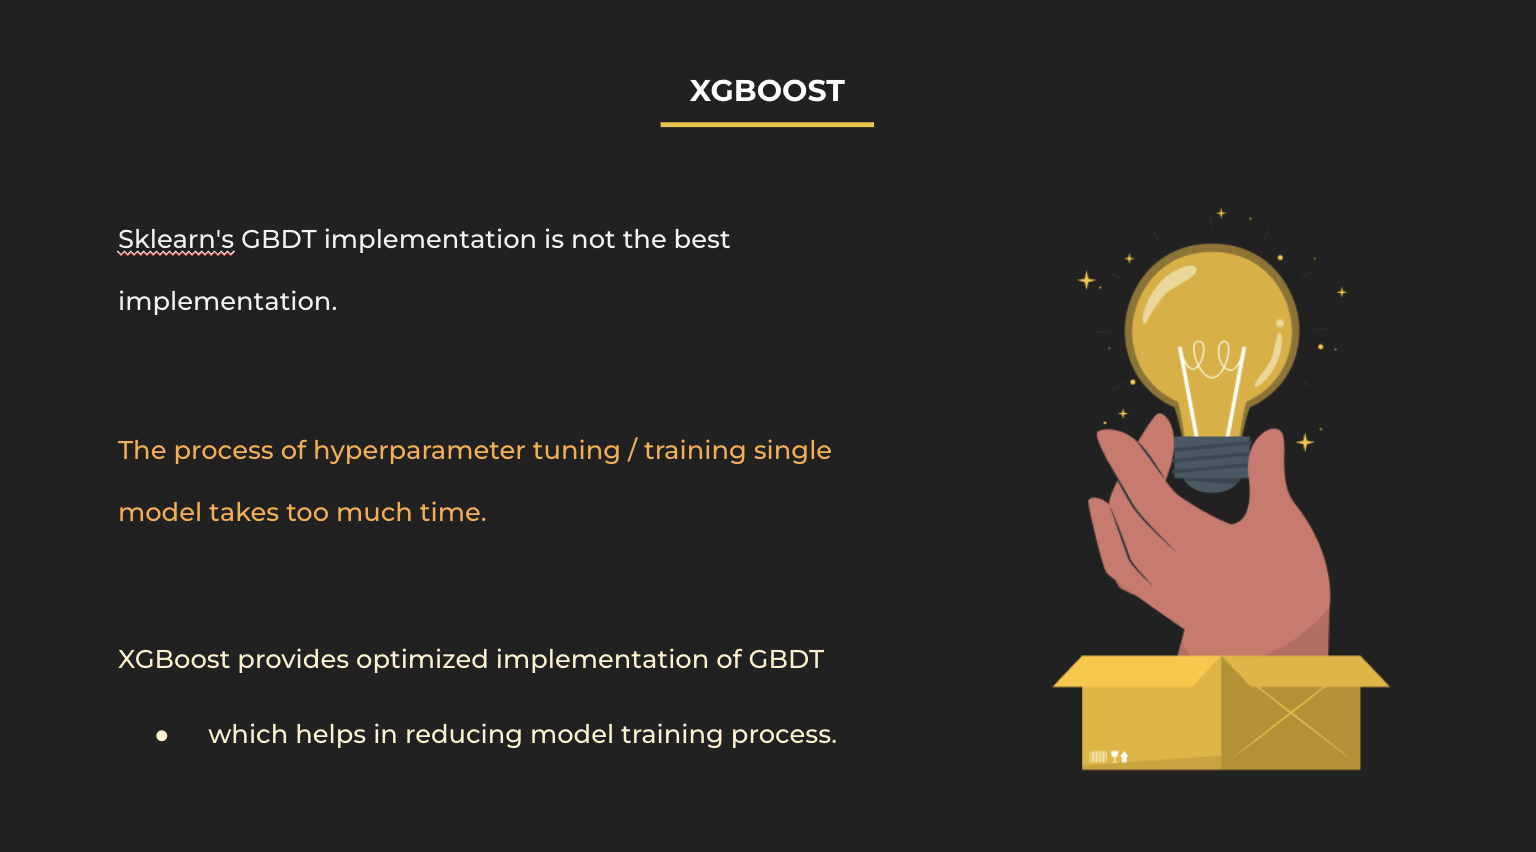

Let's see how it does that

### What optimization does XGBoost provides ?

#### Parallelization of features selection

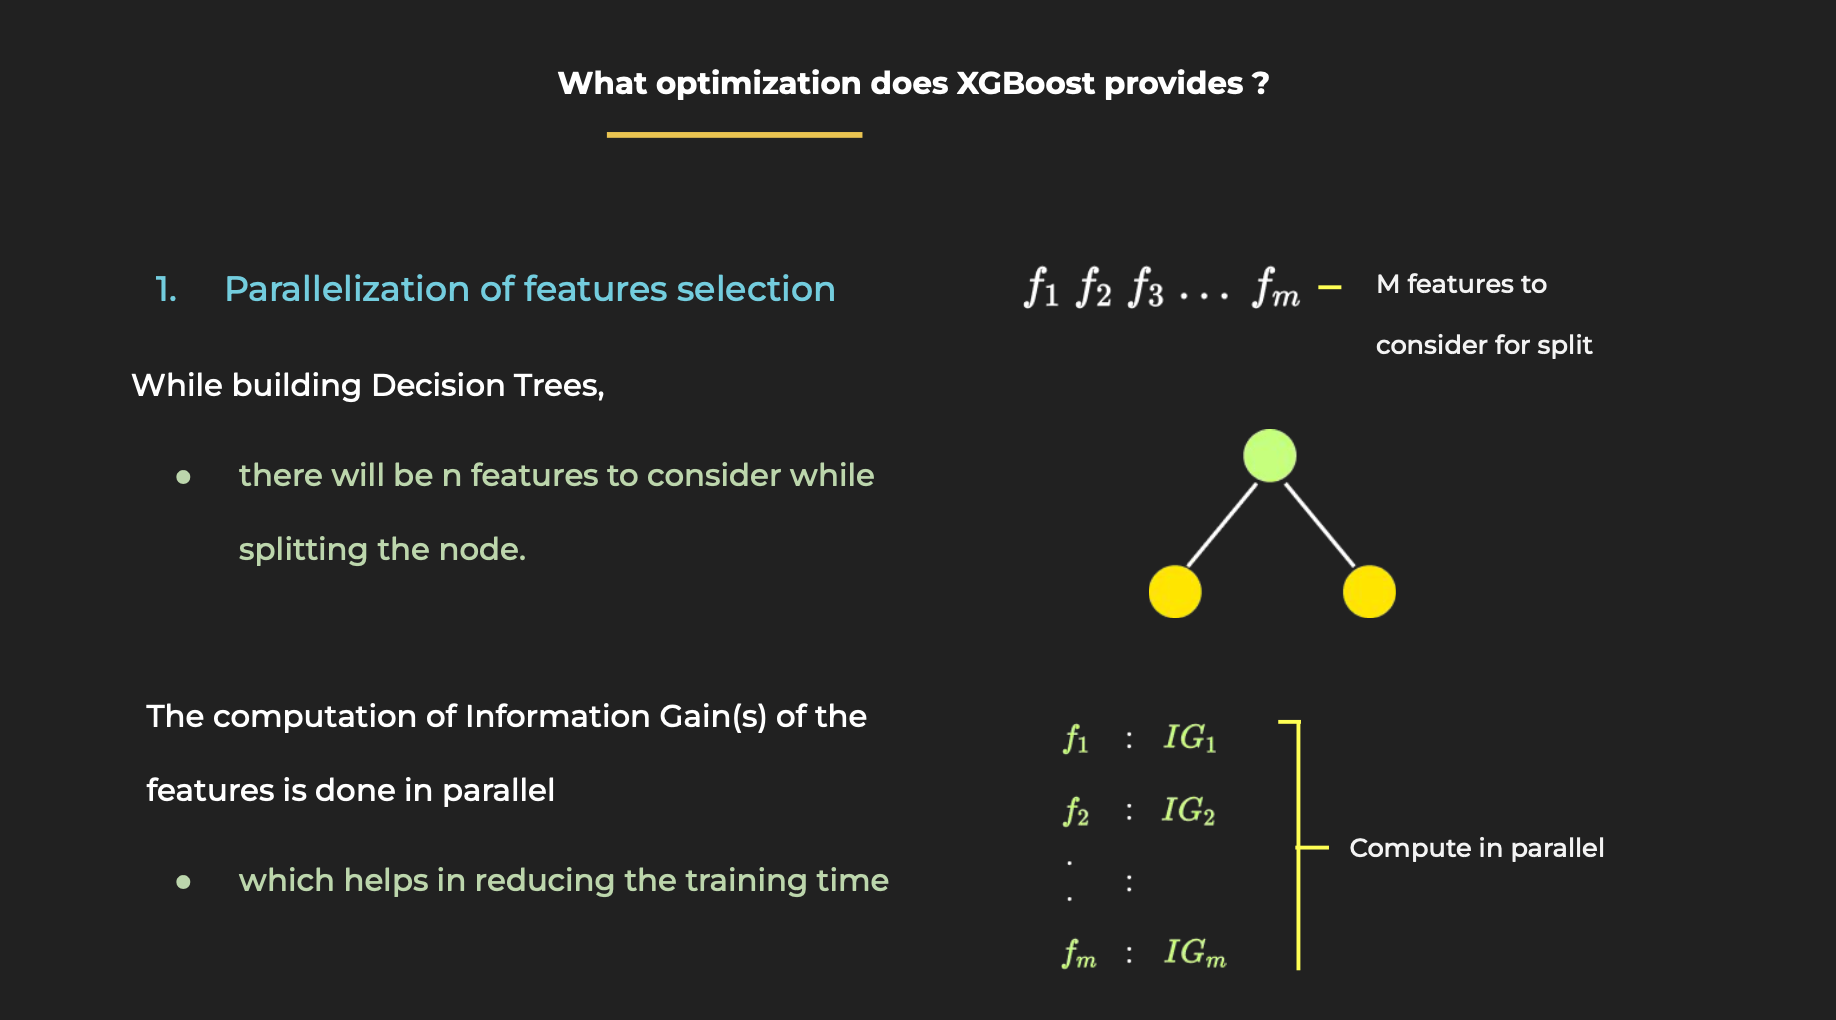

#### Parallelization in building DT

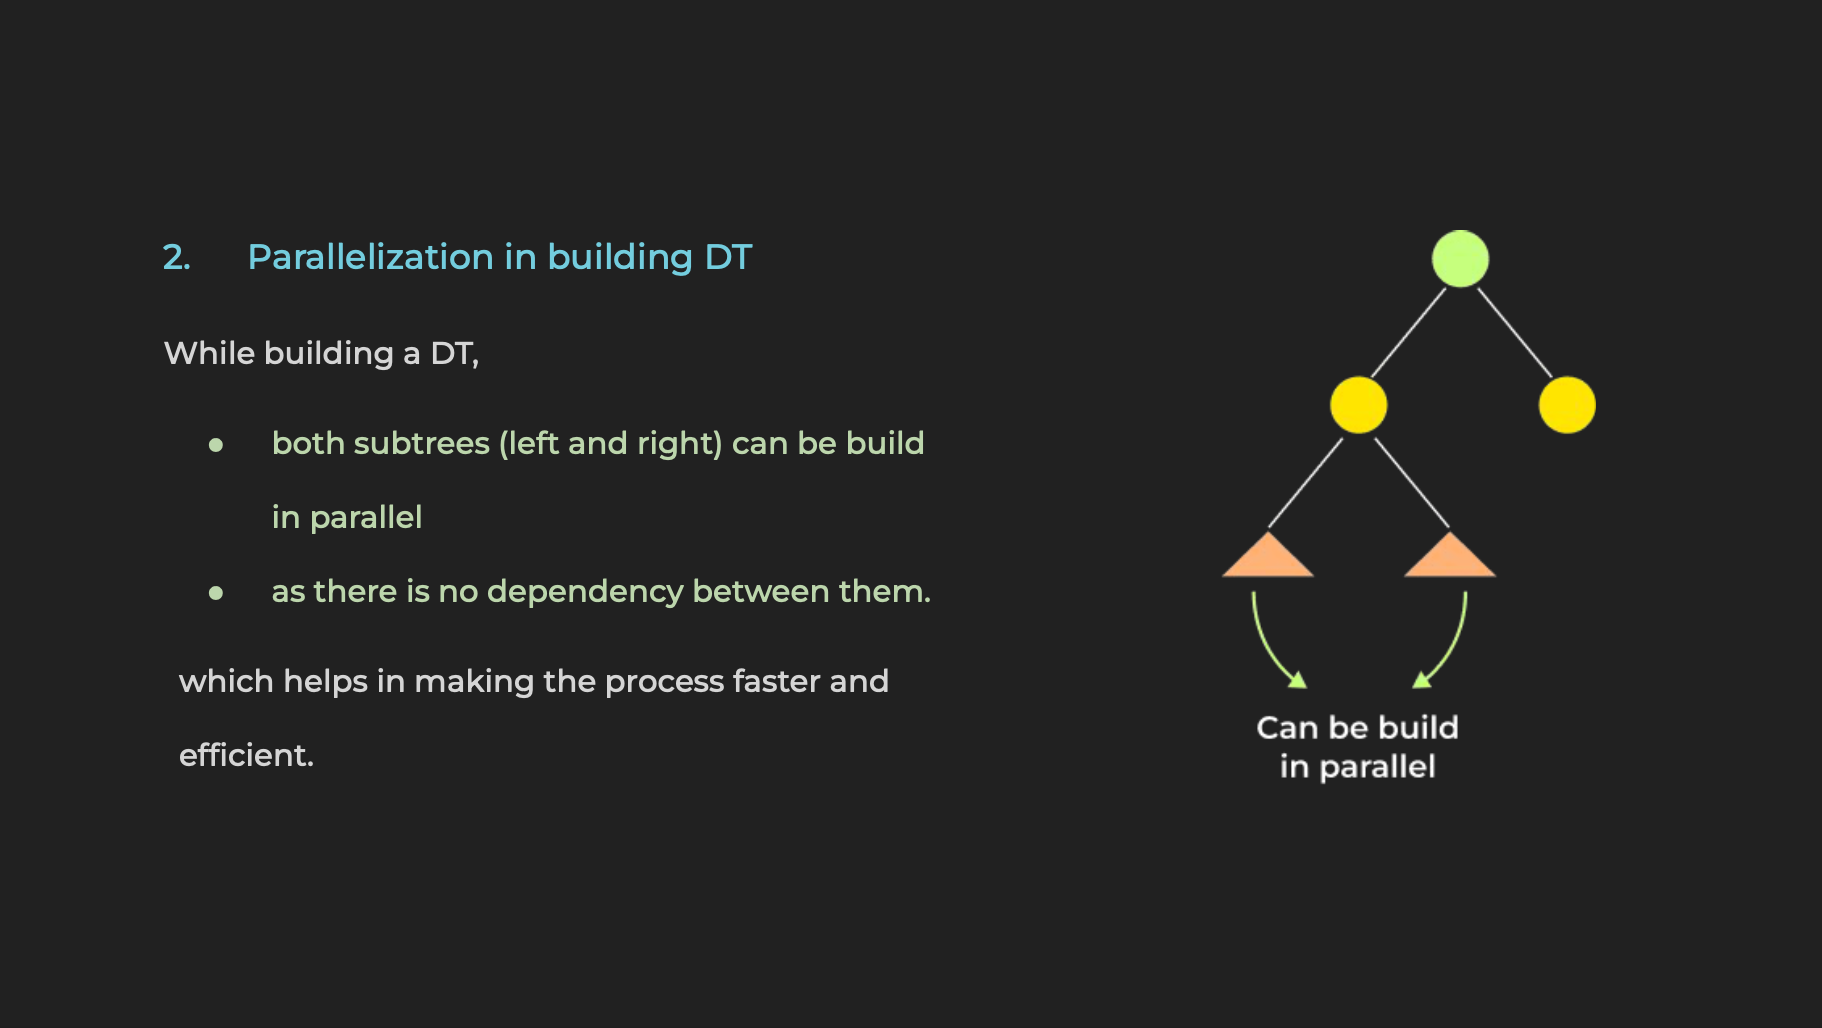

#### Optimizing thresholding in numerical feature

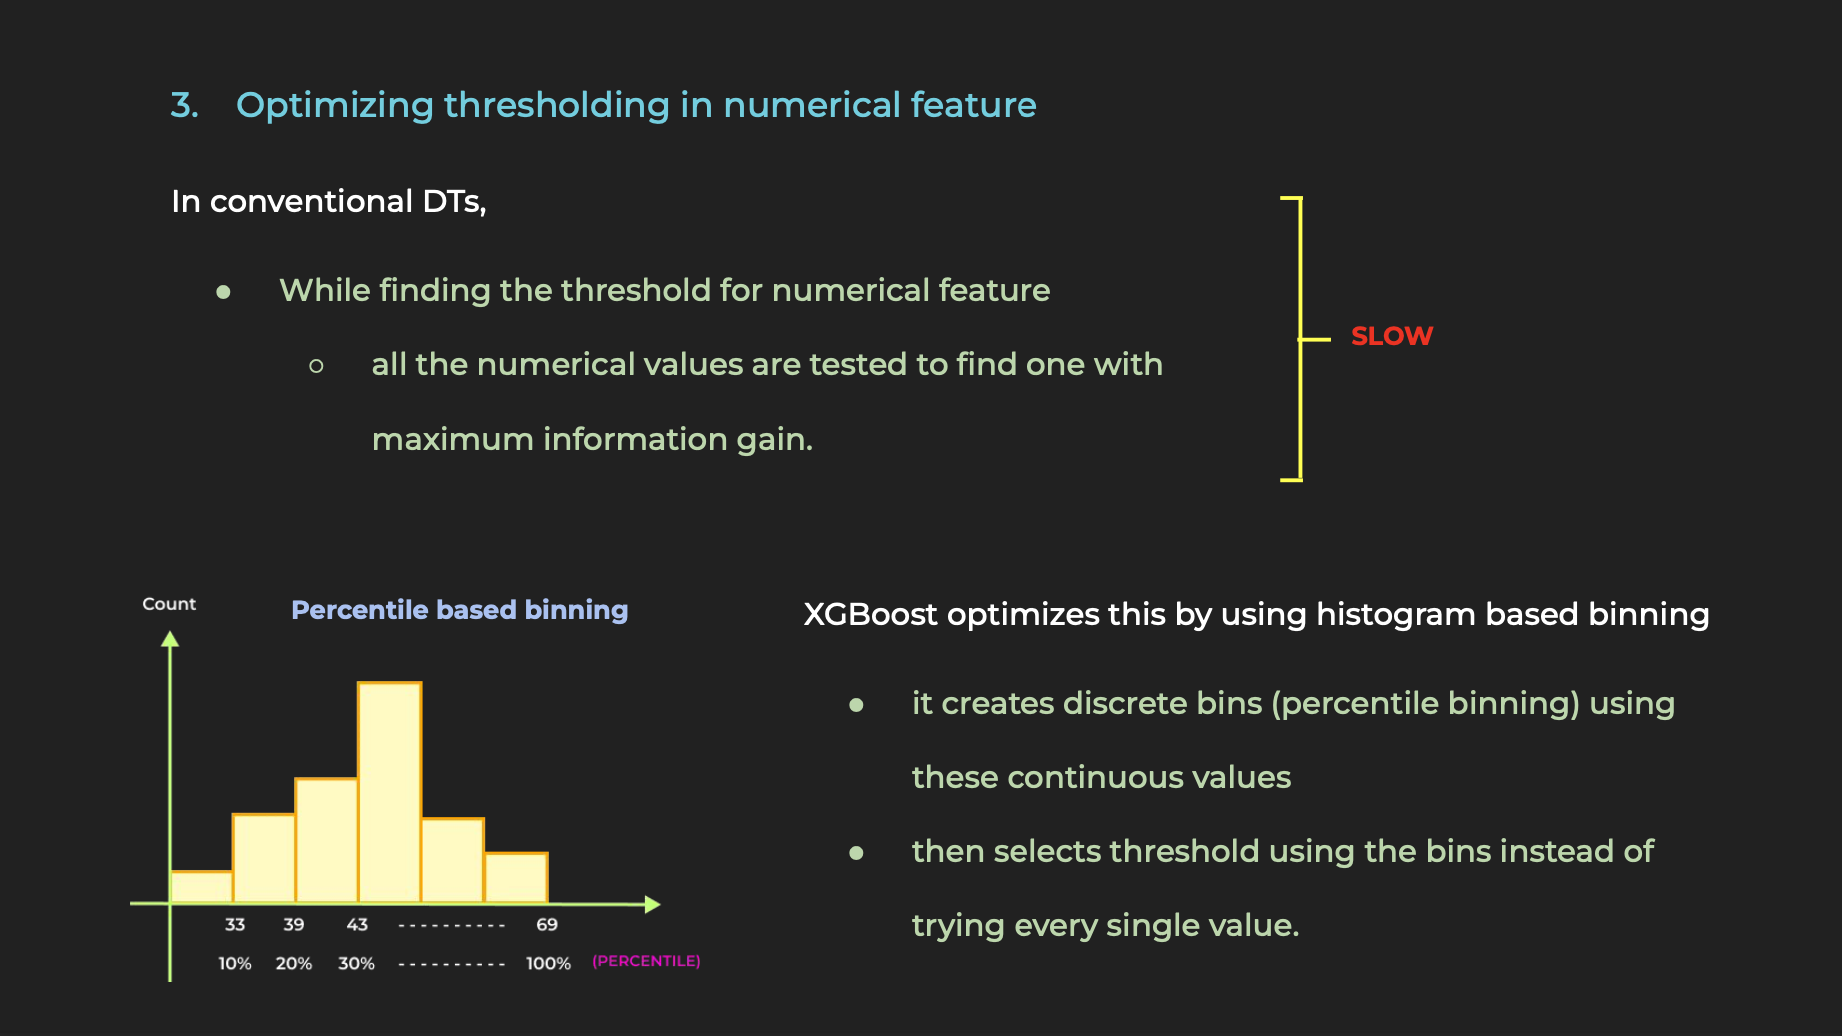

If you want to dive deep into it,

here's the link to the research paper: https://www.kdd.org/kdd2016/papers/files/rfp0697-chenAemb.pdf
- published in 2016

Let's look into the numerous hyperparams provided by XGBoost

### Hyperparameters

XGBoost doc: https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBClassifier

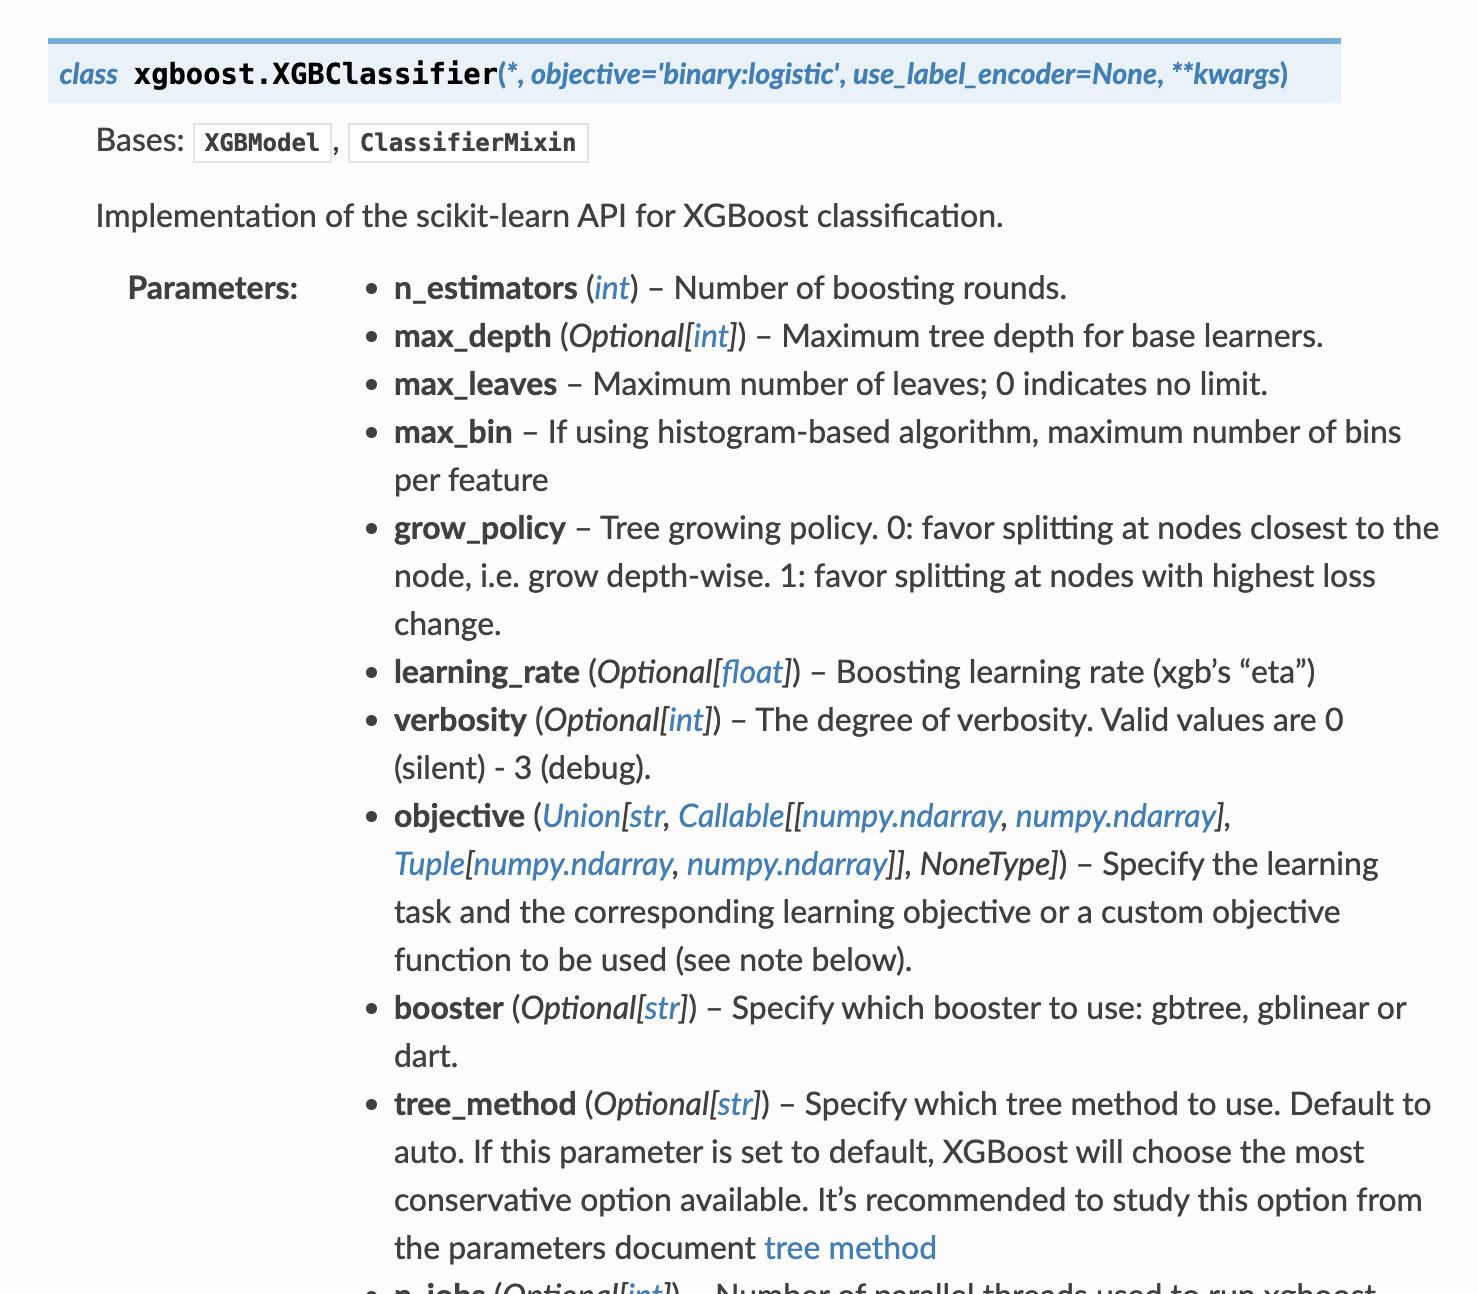

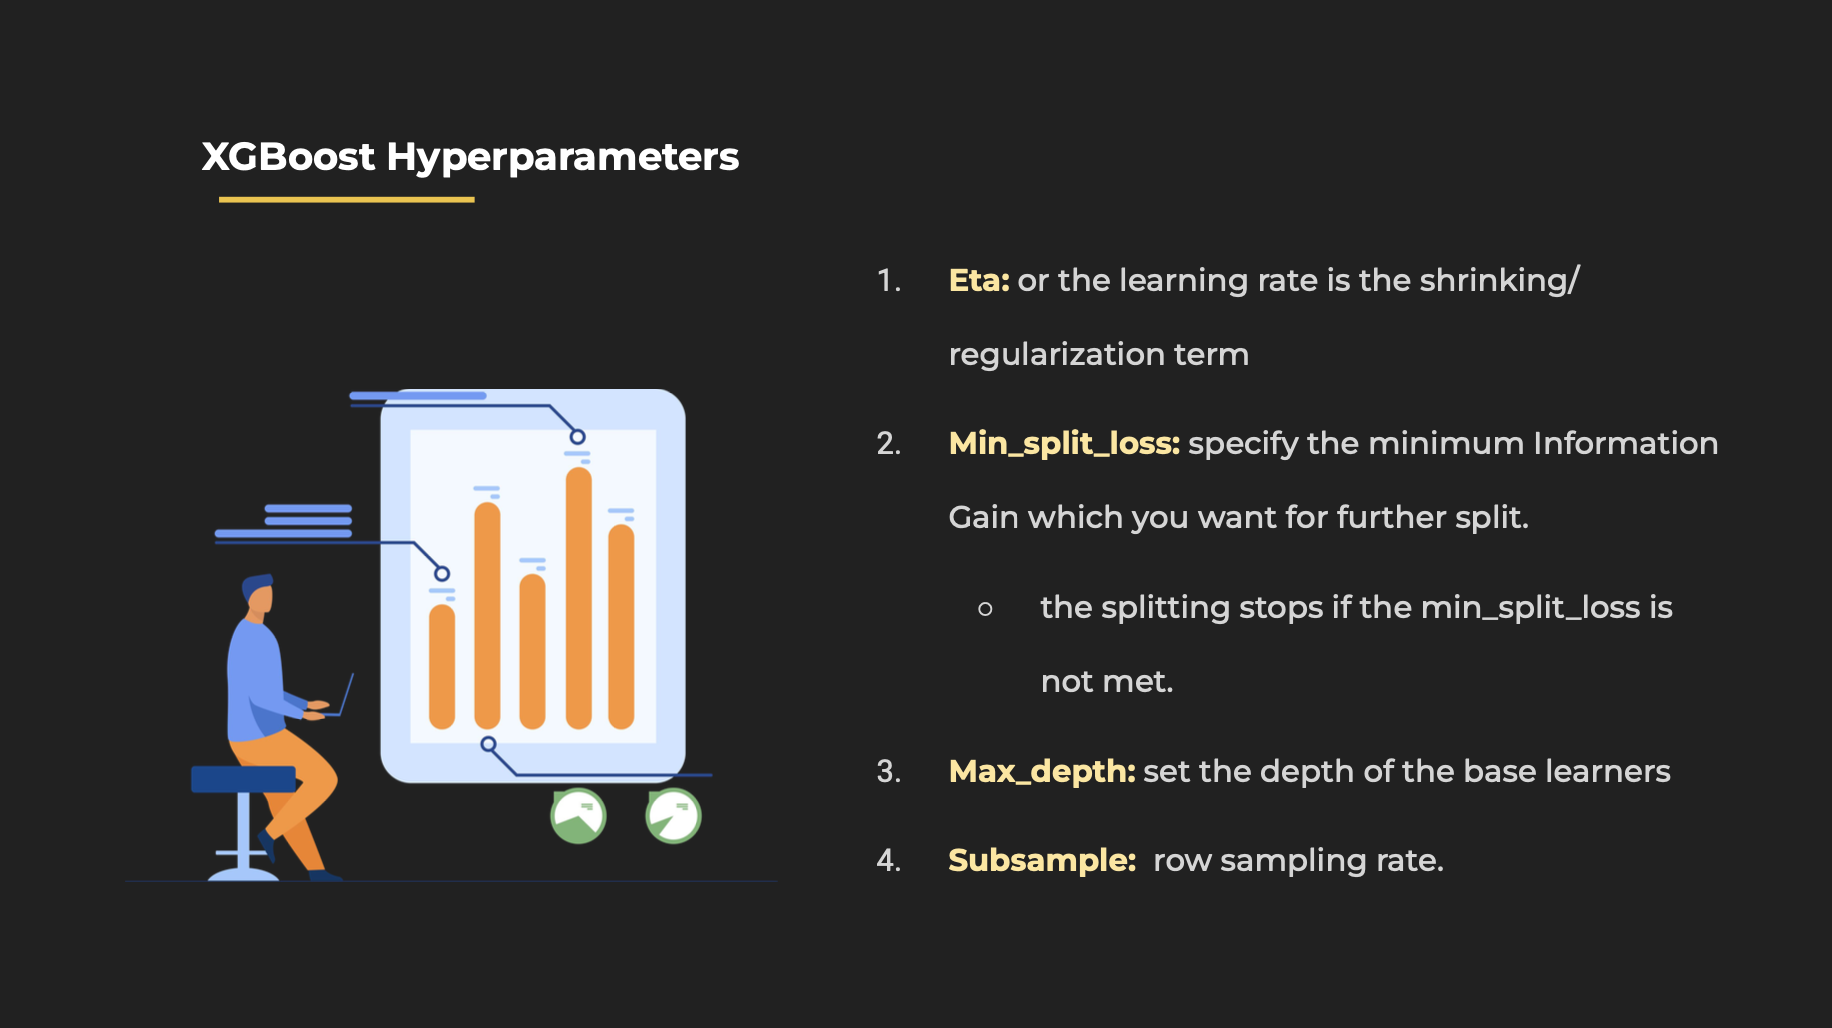

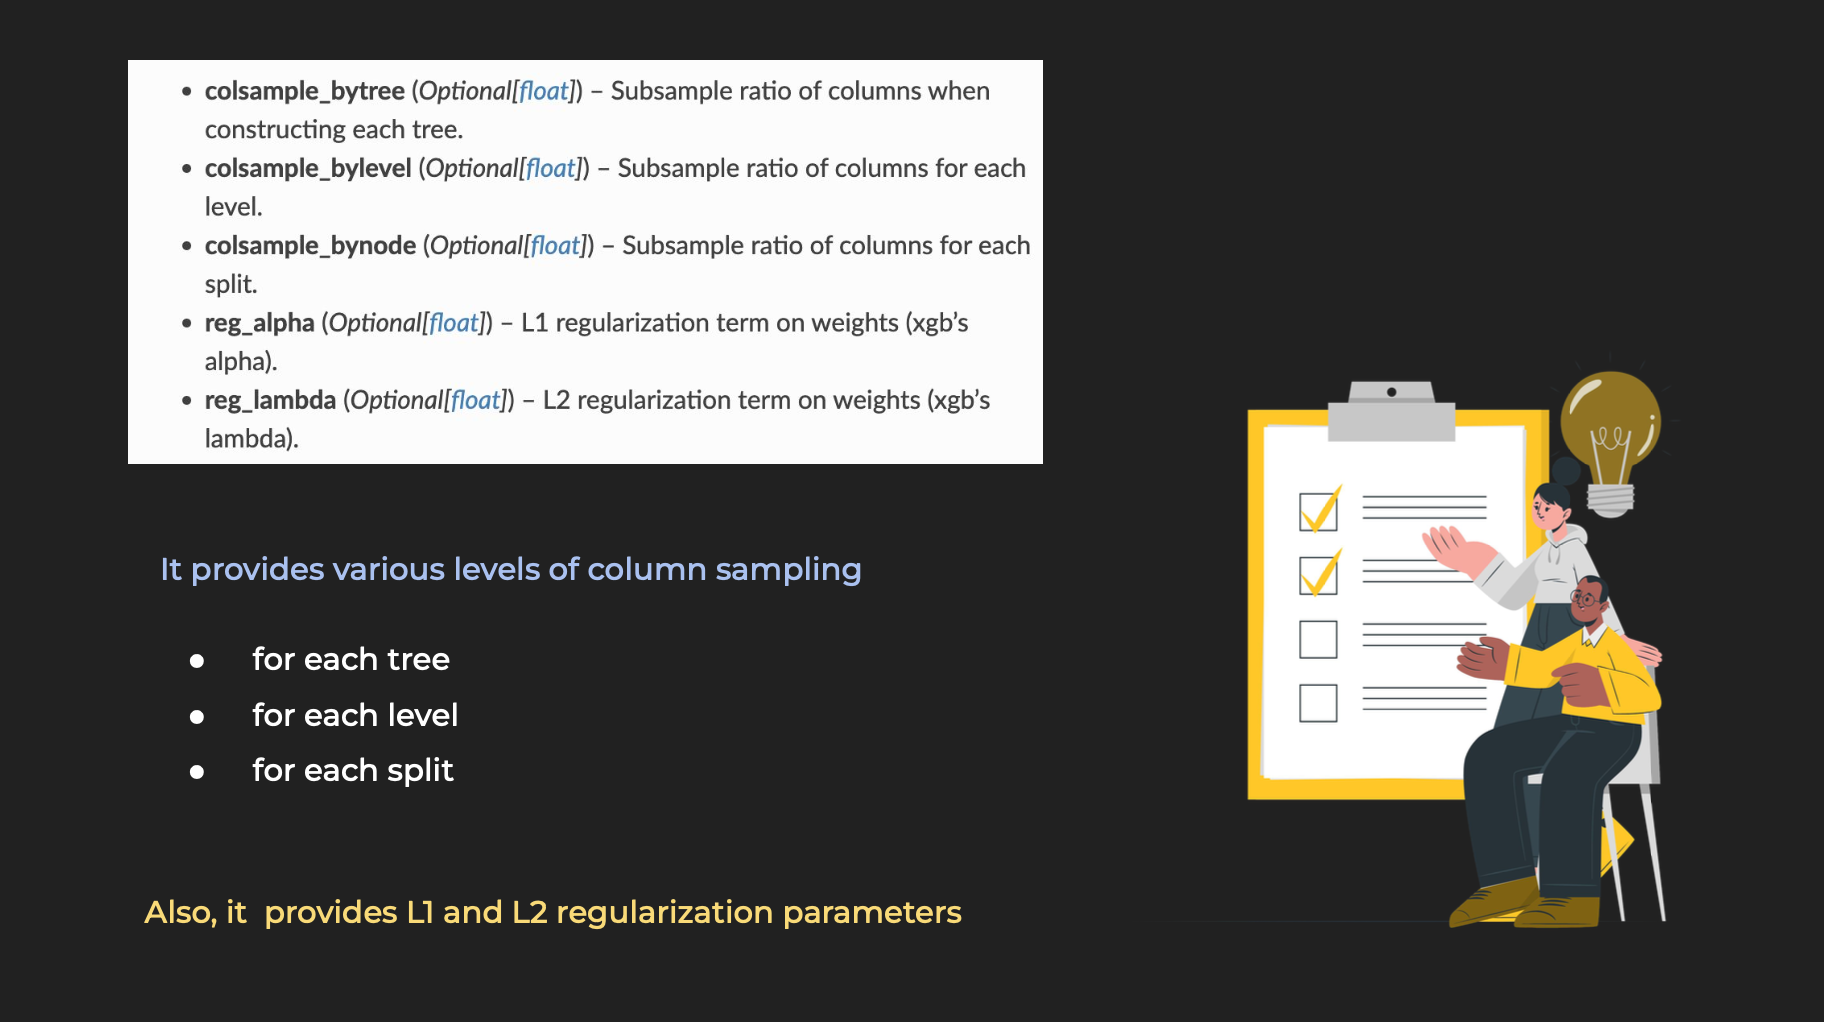

Now that we are aware of the hyperparams,

let's give them a try

### Code walkthrough

In [ ]:
import pickle

!gdown 171Yoe_GSapyrmOnD9oBzHWNOD_OnQs0F
!gdown 1hnIlTPW3AMeB69EbeaXCRIrpMVT1Vwmc
!gdown 1nZtB_RtxMg_MgoRczb8UWQX-AEK_l3qE
!gdown 1zLDUErwKdmF-RacOyHEuI_z_46LssQtP


with open('X_train.pickle', 'rb') as handle:
    X_train = pickle.load(handle)

with open('X_test.pickle', 'rb') as handle:
    X_test = pickle.load(handle)

with open('Y_train.pickle', 'rb') as handle:
    y_train = pickle.load(handle)

with open('Y_test.pickle', 'rb') as handle:
    y_test = pickle.load(handle)

Downloading...
From: https://drive.google.com/uc?id=171Yoe_GSapyrmOnD9oBzHWNOD_OnQs0F
To: /content/Y_test.pickle
100% 31.7k/31.7k [00:00<00:00, 83.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1hnIlTPW3AMeB69EbeaXCRIrpMVT1Vwmc
To: /content/X_test.pickle
100% 253k/253k [00:00<00:00, 129MB/s]
Downloading...
From: https://drive.google.com/uc?id=1nZtB_RtxMg_MgoRczb8UWQX-AEK_l3qE
To: /content/Y_train.pickle
100% 126k/126k [00:00<00:00, 130MB/s]
Downloading...
From: https://drive.google.com/uc?id=1zLDUErwKdmF-RacOyHEuI_z_46LssQtP
To: /content/X_train.pickle
100% 1.01M/1.01M [00:00<00:00, 152MB/s]


In [ ]:

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.model_selection import StratifiedKFold

import datetime as dt

params = {
        "n_estimators": [50,100,150,200],
        "max_depth" : [3, 4, 5, 7],
        "learning_rate": [0.1, 0.2, 0.3],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        }
xgb = XGBClassifier(objective='multi:softmax', num_class=20, silent=True)




In [ ]:

random_search = RandomizedSearchCV(xgb,
                                   param_distributions=params,
                                   n_iter=10,
                                   scoring='accuracy',
                                   n_jobs=-1,
                                   cv=3,
                                   verbose=2)


start = dt.datetime.now()
random_search.fit(X_train, y_train)
end = dt.datetime.now()


Fitting 3 folds for each of 10 candidates, totalling 30 fits
[03:38:03] WARNING: ../src/learner.cc:767: 
Parameters: { "max_leaf_nodes", "silent" } are not used.



In [ ]:
res = random_search.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'subsample': 0.6, 'n_estimators': 200, 'max_leaf_nodes': 80, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 0.6} Mean_score: 0.958523592085236 Rank: 4
Parameters:{'subsample': 0.8, 'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.8} Mean_score: 0.9615677321156774 Rank: 2
Parameters:{'subsample': 1.0, 'n_estimators': 200, 'max_leaf_nodes': 80, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.8} Mean_score: 0.9650558092338914 Rank: 1
Parameters:{'subsample': 0.8, 'n_estimators': 150, 'max_leaf_nodes': 40, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8} Mean_score: 0.9540208016235413 Rank: 6
Parameters:{'subsample': 0.8, 'n_estimators': 100, 'max_leaf_nodes': 40, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.6} Mean_score: 0.9534500253678336 Rank: 7
Parameters:{'subsample': 0.6, 'n_estimators': 150, 'max_leaf_nodes': 20, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytr

In [ ]:
print(f"Time taken for fits : {end - start}")

Time taken for fits : 0:09:44.158693


In [ ]:
print(random_search.best_estimator_)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaf_nodes=80,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_class=20, num_parallel_tree=None, ...)


In [ ]:
xgb = random_search.best_estimator_

xgb.fit(X_train, y_train)

print("Model acc",xgb.score(X_test, y_test))



[03:45:08] WARNING: ../src/learner.cc:767: 
Parameters: { "max_leaf_nodes", "silent" } are not used.

Model acc 0.9807253360385493


Notice that
- It took us 10 mins to hyperparam tune XGB vs > 30 mins in sklearn GBDT


## LightGBM

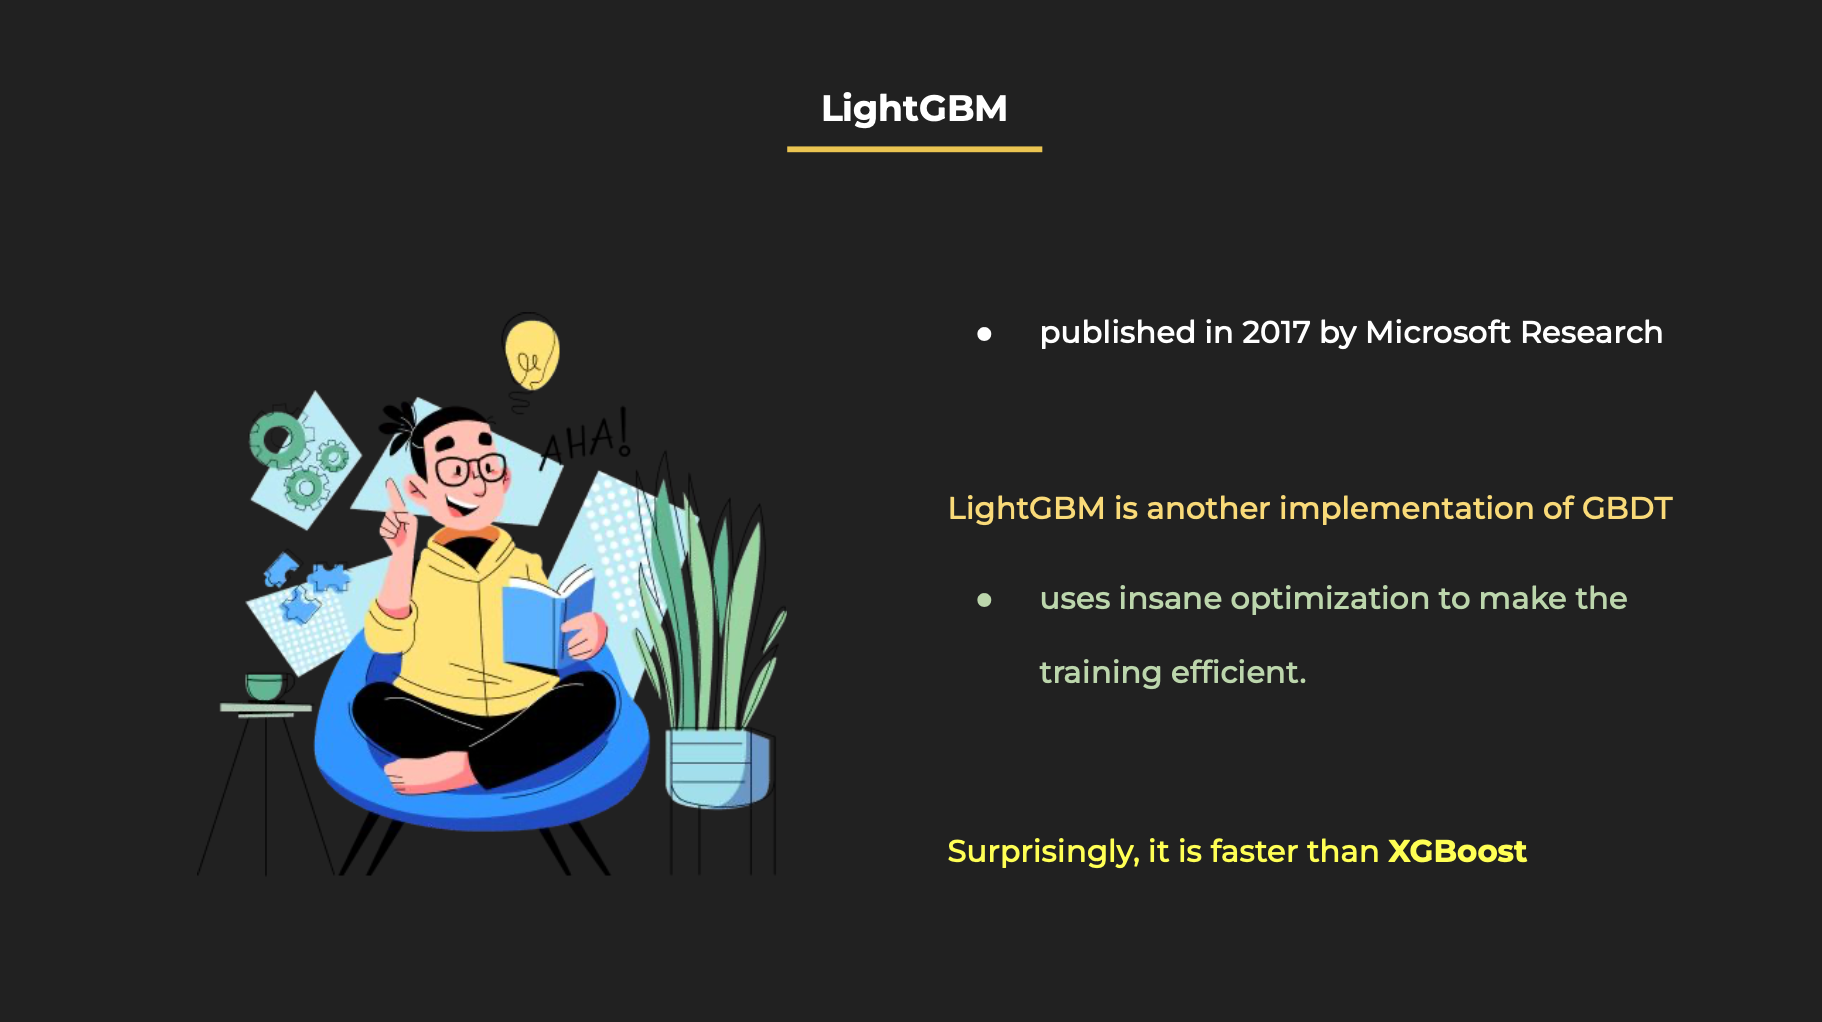

Research paper link: https://proceedings.neurips.cc/paper_files/paper/2017/file/6449f44a102fde848669bdd9eb6b76fa-Paper.pdf



### What makes LightGBM faster?

```
Quiz - Try it out

How can we make an algo train faster?

a. reduce number of datapoints
b. reduce number of features
c. Both
d. None of the aboe

Ans: c. Both

Reducing the number of datapoint or features will help algo train faster.
```

This is what LightGBM does with its optimization

 Let's look into that

#### GOSS (Gradient-based One-Side Sampling)

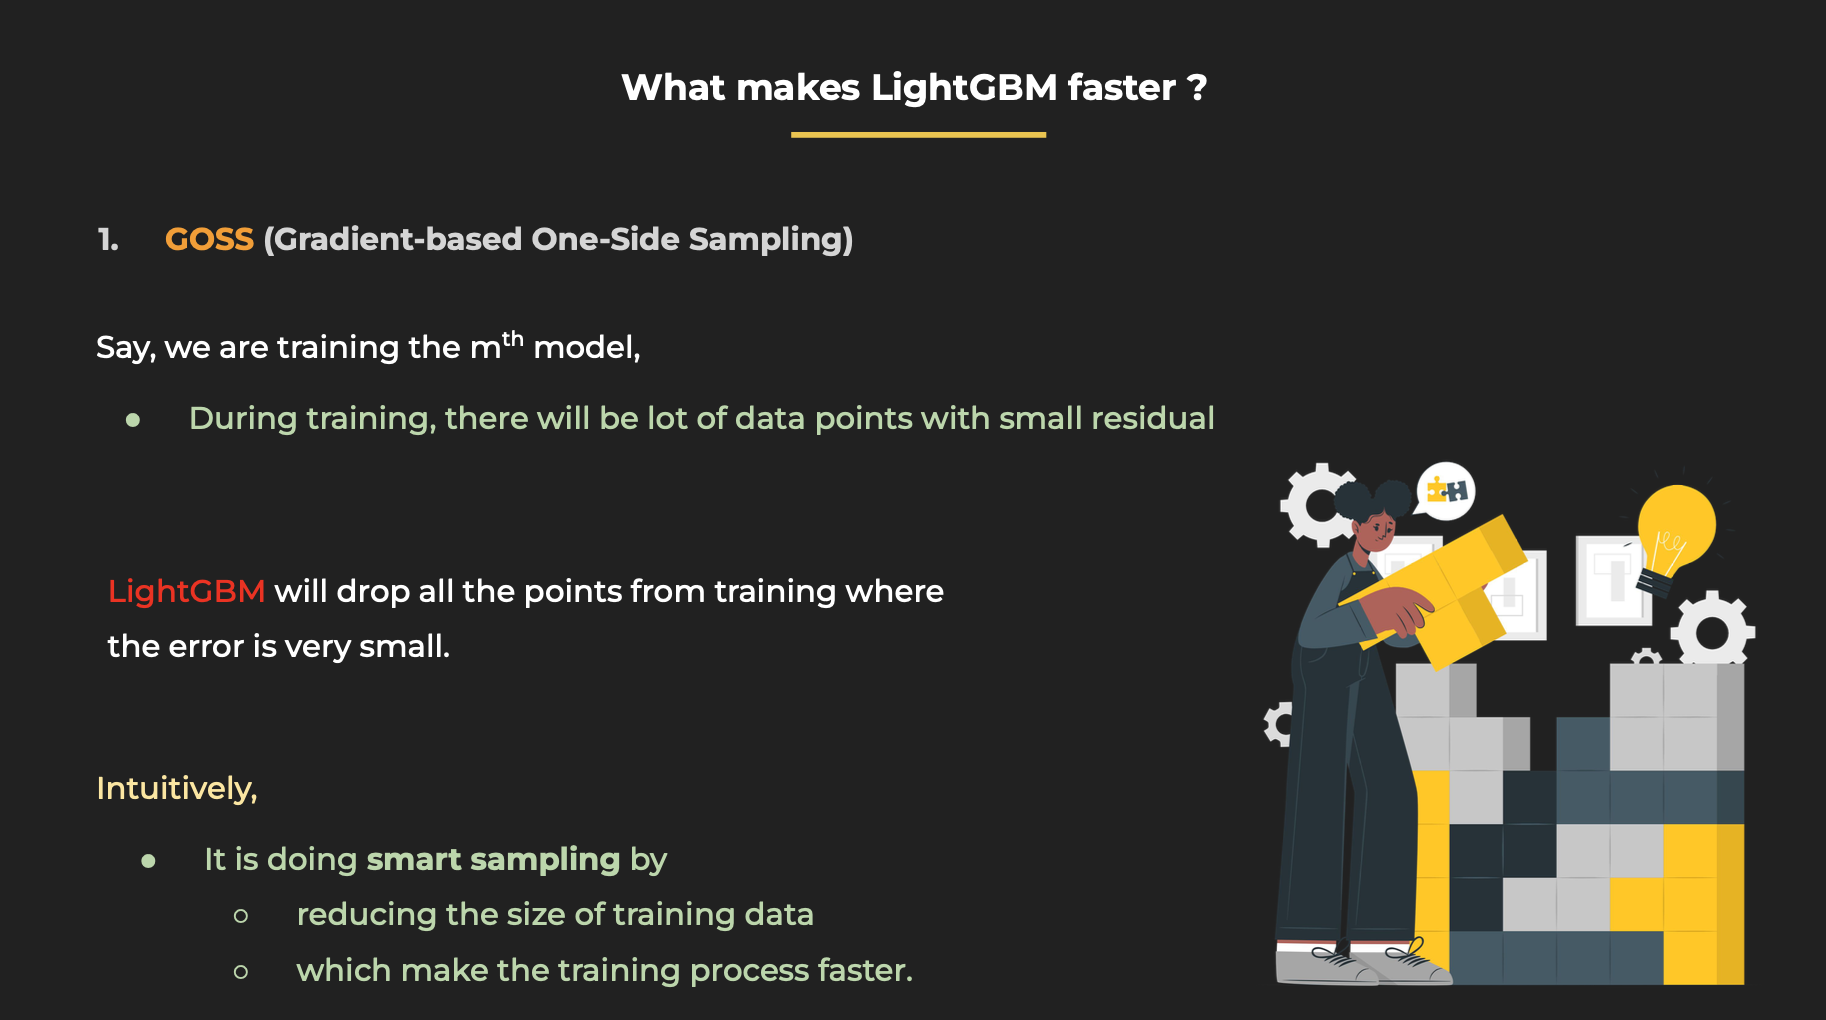

#### But, what does one side sampling means ?

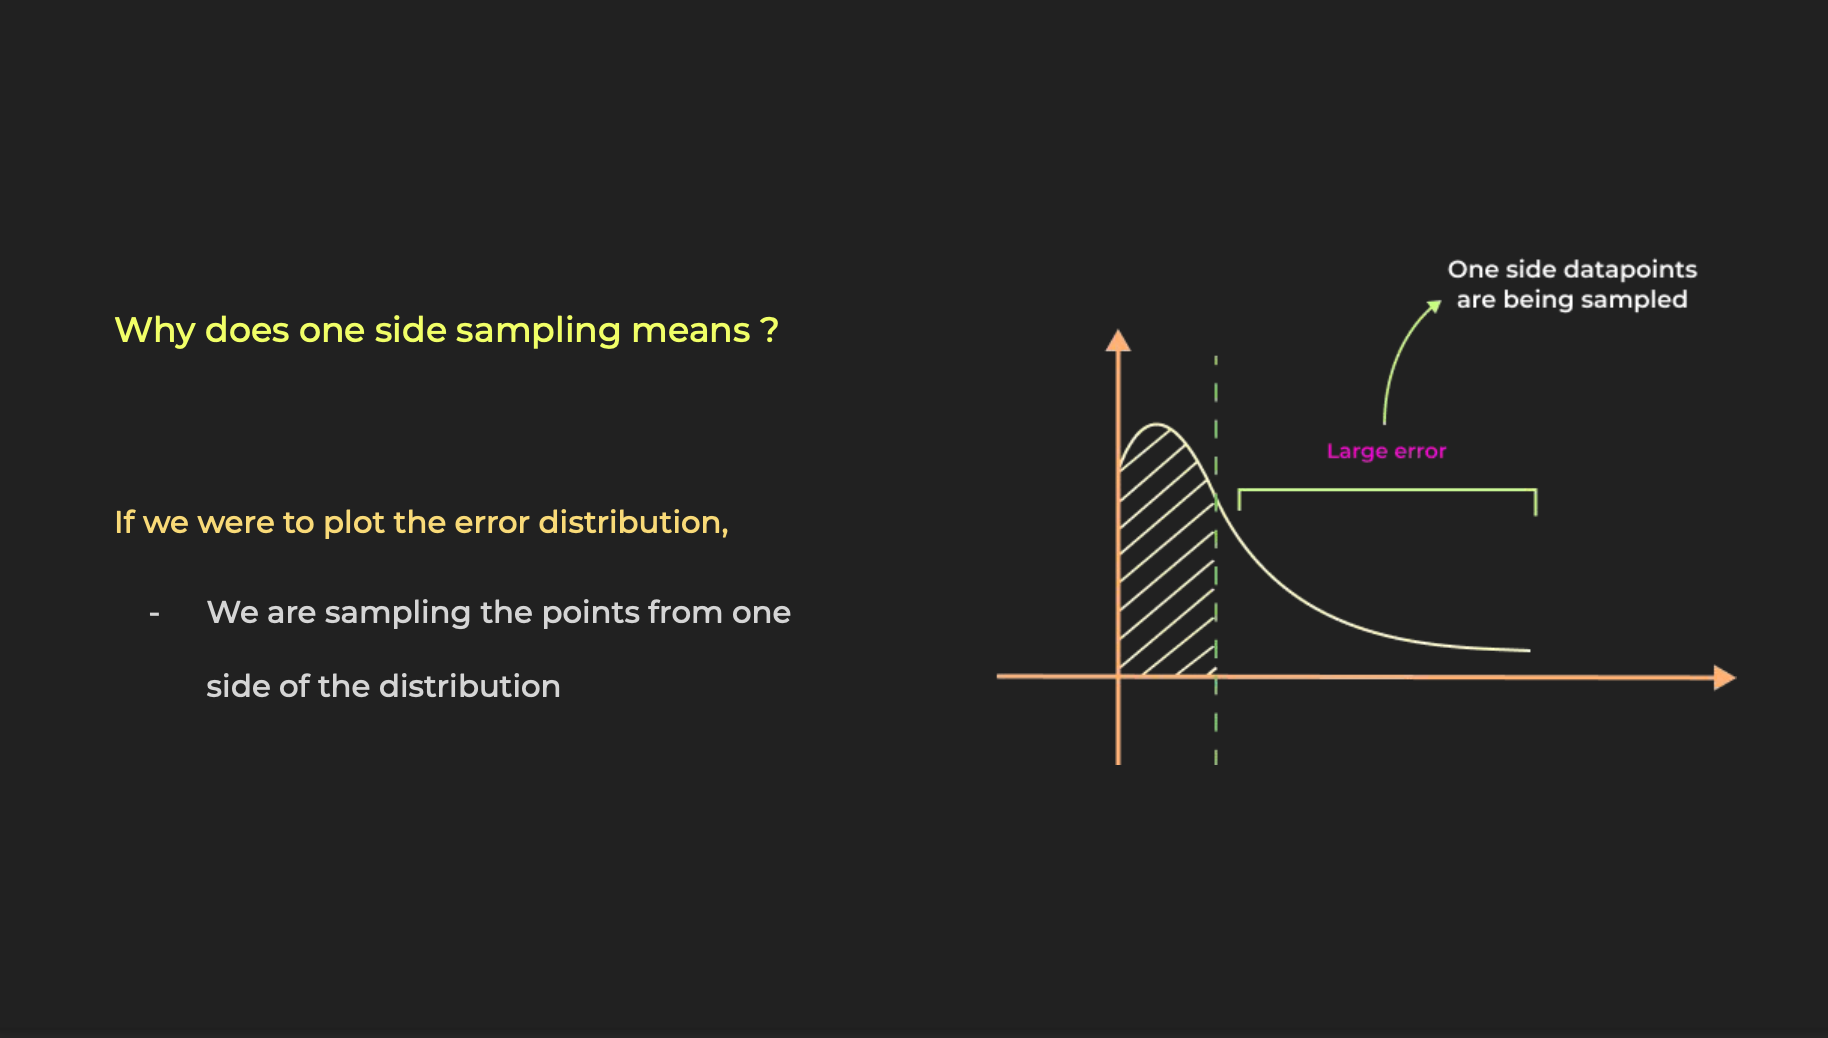

Moving on to next optimization

#### EFB (Exclusive Feature Bundling)

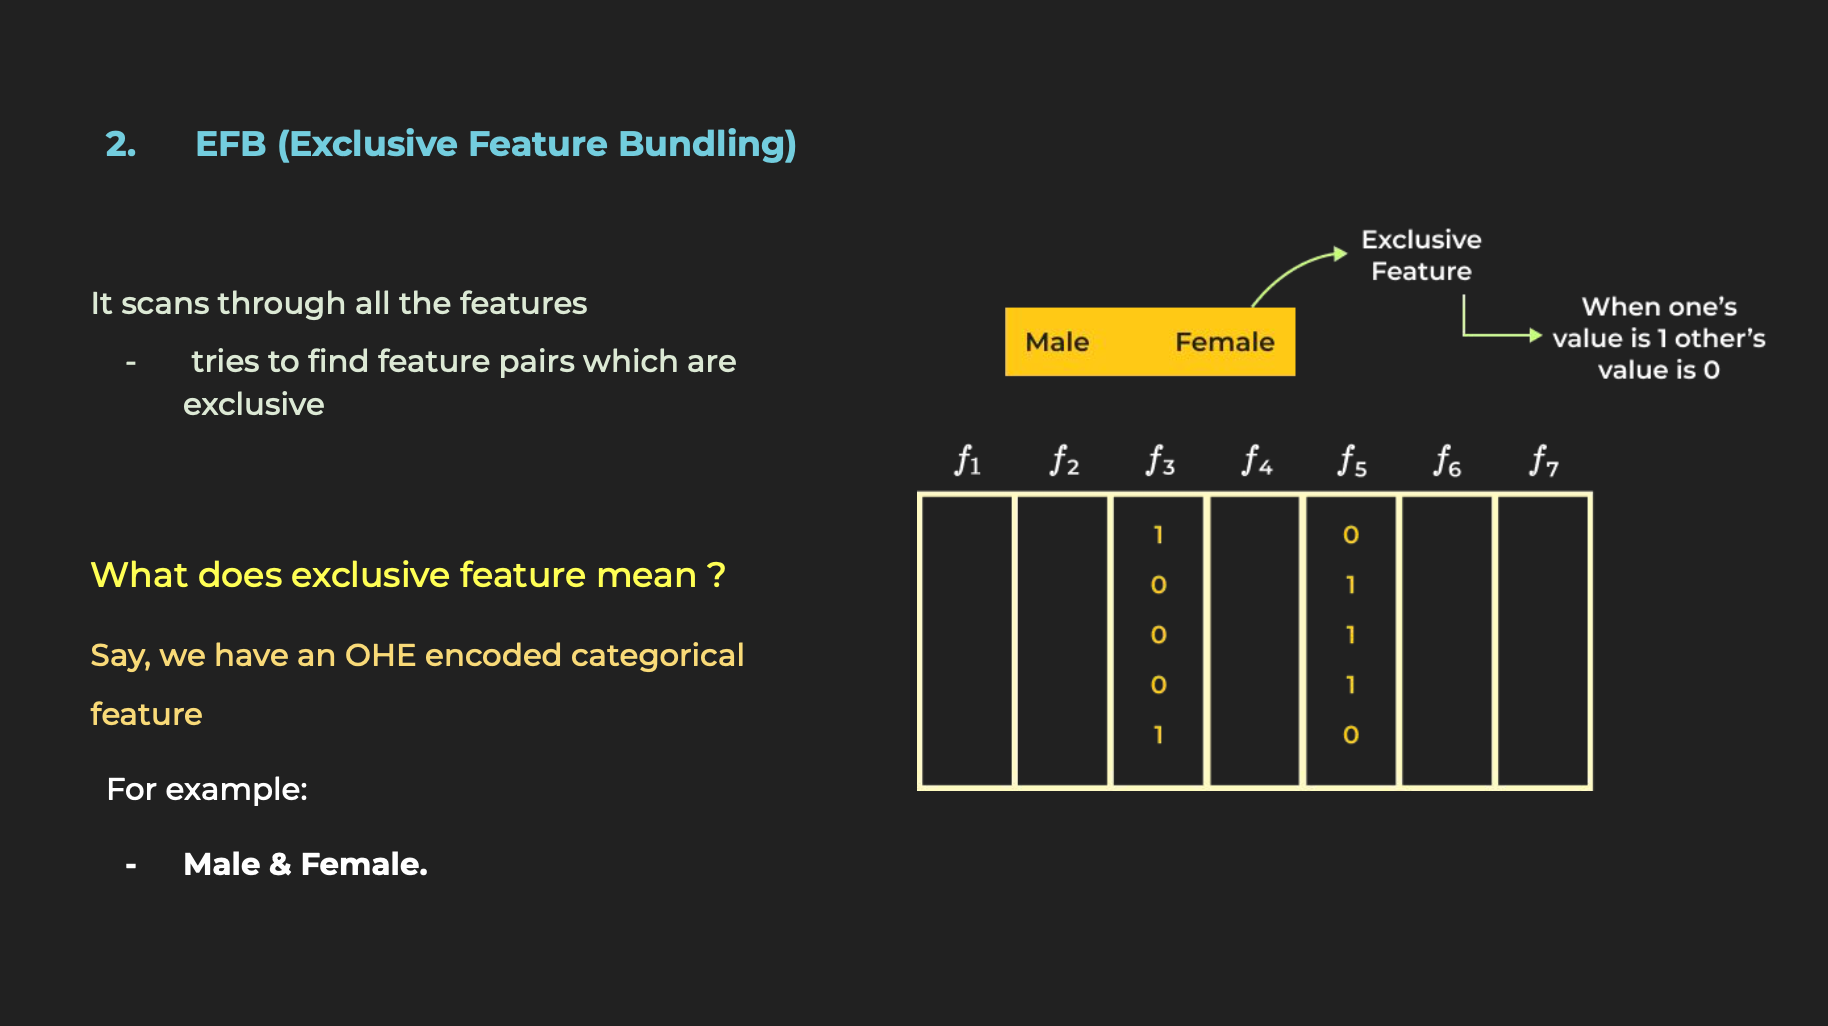

#### But, it is obvious that when Male feature value is 1, female feature value will be zero.

Yes.
But
- a problem has numerous features
- and we can't check manually which features are exclusive

There can be a case where two categorical features
- say, for example:
    - binary feature: whether person likes football ?
    - and another feature: whether person likes swimming ?

There can be chance that this pair of feature is exclusive for the given dataset.

#### What happens after it has identified Exclusive feature pair ?

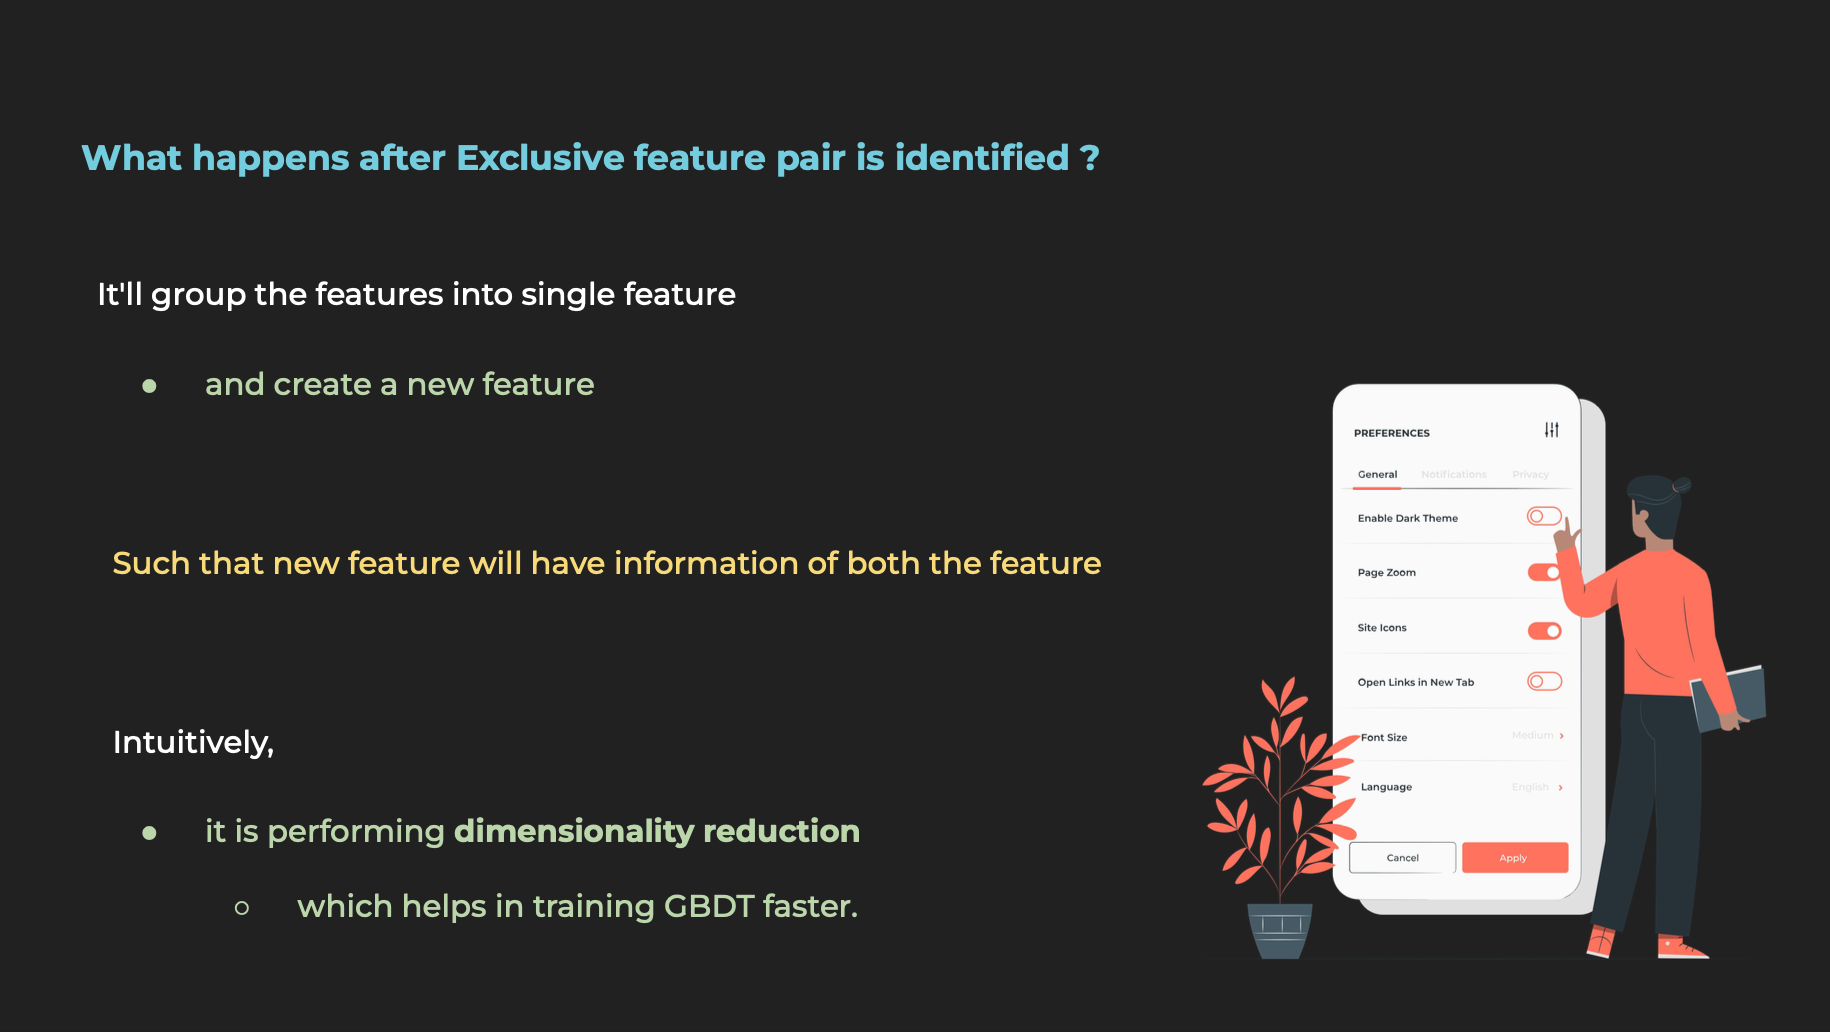

If you want to deep dive into it,

here a blog explaining it in detail: https://towardsdatascience.com/what-makes-lightgbm-lightning-fast-a27cf0d9785e

Let's look into how can we implement it

### Code walkthough

Documentation: https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
#Refer: https://lightgbm.readthedocs.io/en/latest/Parameters.html
import datetime as dt
gridParams = {
    'learning_rate': [0.1, 0.3, 0.5],
    'boosting_type' : ['gbdt'],
    'objective' : ['multiclass'],
    'max_depth' : [5,6,7,8],
    'colsample_bytree' : [0.5,0.7],
    'subsample' : [0.5,0.7],
    'metric':['multi_error'],
    }

clf = lgb.LGBMClassifier(num_classes=20)
random_cv = RandomizedSearchCV(clf,gridParams,verbose=3,cv=3,n_jobs = -1,n_iter=10)



In [ ]:
start = dt.datetime.now()
random_cv.fit(X_train,y_train)
end = dt.datetime.now()


Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [ ]:
res = random_cv.cv_results_

for i in range(len(res["params"])):
  print(f"Parameters:{res['params'][i]} Mean_score: {res['mean_test_score'][i]} Rank: {res['rank_test_score'][i]}")


Parameters:{'subsample': 0.7, 'objective': 'multiclass', 'metric': 'multi_error', 'max_depth': 8, 'learning_rate': 0.5, 'colsample_bytree': 0.7, 'boosting_type': 'gbdt'} Mean_score: 0.16324200913242007 Rank: 7
Parameters:{'subsample': 0.5, 'objective': 'multiclass', 'metric': 'multi_error', 'max_depth': 7, 'learning_rate': 0.3, 'colsample_bytree': 0.7, 'boosting_type': 'gbdt'} Mean_score: 0.9692415017757483 Rank: 1
Parameters:{'subsample': 0.7, 'objective': 'multiclass', 'metric': 'multi_error', 'max_depth': 8, 'learning_rate': 0.3, 'colsample_bytree': 0.7, 'boosting_type': 'gbdt'} Mean_score: 0.9681633688483003 Rank: 2
Parameters:{'subsample': 0.7, 'objective': 'multiclass', 'metric': 'multi_error', 'max_depth': 5, 'learning_rate': 0.5, 'colsample_bytree': 0.5, 'boosting_type': 'gbdt'} Mean_score: 0.1513191273465246 Rank: 9
Parameters:{'subsample': 0.5, 'objective': 'multiclass', 'metric': 'multi_error', 'max_depth': 8, 'learning_rate': 0.5, 'colsample_bytree': 0.7, 'boosting_type': '

In [ ]:
print(f"Time taken for fits : {end - start}")

Time taken for fits : 0:00:57.177334


In [ ]:
print(random_cv.best_estimator_)

LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=7,
               metric='multi_error', num_classes=20, objective='multiclass',
               subsample=0.5)


In [ ]:
lgb = random_cv.best_estimator_

lgb.fit(X_train, y_train)

print("Model acc",lgb.score(X_test, y_test))



Model acc 0.9835150900329698


Notice that
- It only took 57 sec to train
- and its performance is comparable to XGBoost implementation